
# **📊 BUSINESS ANALYSIS PROJECT: SHOPEE SALES DATA**

**Author  : Rizky Faza Hafiyyan Nusantara**

 **Role    : Business/Data Analyst**

 **Tools   : Python (Pandas, Matplotlib, Seaborn)**

 **Objective: Analyze factors affecting product sales performance**


In [1]:
# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Setting visual style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ Library berhasil diimport!")

✅ Library berhasil diimport!


In [2]:
# ================================================================
# 2. LOAD DATA
# ================================================================

df = pd.read_csv('/content/Shopee_Sales_Dataset.csv')

print(f"📌 Dataset Shape: {df.shape}")
print("\n🔍 5 Data Pertama:")
df.head()

📌 Dataset Shape: (20312, 20)

🔍 5 Data Pertama:


,price_ori,delivery,item_category_detail,specification,title,w_date,link_ori,item_rating,seller_name,idElastic,price_actual,sitename,idHash,total_rating,id,total_sold,pict_link,favorite,timestamp,desc
0,25.80,"KL City, Kuala Lumpur",Shopee | Women's Bags | Shoulder Bags | Should...,Product Specifications Category Shopee Women's...,1081 PU SLING BAG KULIT leather Casual Beg Tan...,2023-04-27,https://shopee.com.my/1081-PU-SLING-BAG-KULIT-...,4.9,qqfwholesale,19ec9fdedd9fe3e14bc652950fc3c423,12.90,shopee,88f051f0a2dcf0d29191e0175b828938,179,88f051f0a2dcf0d29191e0175b828938,179,https://down-my.img.susercontent.com/file/my-1...,Favorite (128,1682553600000,🎉 WELCOME To QQF WHOLESALE \r\n😍 ALL item read...
1,1.41,NaN,Shopee | Home Appliances | Sewing Machines | S...,Product Specifications Category Shopee Home Ap...,Stat Chinese Traditional Frog Buttons Knot Che...,2023-04-27,https://shopee.com.my/Stat-Chinese-Traditional...,5.0,stationery.my,5322309be3b6d9c01d15fa19f5b7ad9a,0.75,shopee,472d22f58af3bb35cf28c6eed7088dc5,17,472d22f58af3bb35cf28c6eed7088dc5,17,https://down-my.img.susercontent.com/file/4147...,Favorite (19,1682553600000,Chinese Traditional Frog Buttons Knot Cheongsa...
2,8.50,"KL City, Kuala Lumpur",Shopee | Women's Bags | Handbags | Set Handbags,Product Specifications Category Shopee Women's...,N09 READY STOCK MYFOOYIN woman handbag set 2in...,2023-04-26,https://shopee.com.my/N09-READY-STOCK-MYFOOYIN...,4.9,fooyin88,7a36765d1e2ca2b6a5414ddfeedfefc3,8.50,shopee,ec6ce64f4b77efb38b6392818959f181,8.1k,ec6ce64f4b77efb38b6392818959f181,8.1k,https://down-my.img.susercontent.com/file/23da...,Favorite (21.5k,1682467200000,READY STOCK\nMEASUREMENT:\nLONG 26CM X HEIGHT ...
3,8.70,NaN,Shopee | Women Clothes | Maternity Wear | Inne...,Product Specifications Category Shopee Women C...,🔥Shocking Sale🔥Cotton Comfort Nursing Bra Brea...,2023-04-26,https://shopee.com.my/%F0%9F%94%A5Shocking-Sal...,4.9,vivi2002,7fc4ab69722e4f788f217b4c044f83eb,8.70,shopee,ef4e0e17fdc7d0125d8609dcc395bc3d,6.5k,ef4e0e17fdc7d0125d8609dcc395bc3d,6.5k,https://down-my.img.susercontent.com/file/df47...,Favorite (3.4k,1682467200000,PRODUCT DESCRIPTION\nMaterial:95%Cotton+5%Span...
4,3999.00,"KL City, Kuala Lumpur",Shopee | Cameras & Drones | DSLR Cameras | DSLRs,Product Specifications Category Shopee Cameras...,Canon EOS 70D 18-55mm IS STM Original+64gb+ext...,2023-04-26,https://shopee.com.my/Canon-EOS-70D-18-55mm-IS...,5.0,xpro.gadget,55608f901f4c5384f884de18227d4298,2739.00,shopee,568c2029fed7d22973ff96d0404a8ff8,10,568c2029fed7d22973ff96d0404a8ff8,10,https://down-my.img.susercontent.com/file/4d3a...,Favorite (132,1682467200000,Canon 70D\nHighlights\nEF-S 18-55mm f/3.5-5.6 ...


In [3]:
# ================================================================
# 3. DATA UNDERSTANDING
# ================================================================

print("\n📌 Data Info:")
df.info()

print("\n📌 Statistical Summary:")
df.describe()

# Cek kolom yang tersedia
print("\n📌 Kolom yang tersedia:")
print(df.columns.tolist())


📌 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20312 entries, 0 to 20311
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price_ori             20112 non-null  float64
 1   delivery              6558 non-null   object 
 2   item_category_detail  20312 non-null  object 
 3   specification         20301 non-null  object 
 4   title                 20312 non-null  object 
 5   w_date                20312 non-null  object 
 6   link_ori              20312 non-null  object 
 7   item_rating           20301 non-null  object 
 8   seller_name           20301 non-null  object 
 9   idElastic             20312 non-null  object 
 10  price_actual          20297 non-null  float64
 11  sitename              20312 non-null  object 
 12  idHash                20312 non-null  object 
 13  total_rating          20301 non-null  object 
 14  id                    20312 non-null  object 
 15  total

**DATA CLEANING**

In [25]:
# Gabungkan kolom menjadi satu kolom datetime
df['review'] = pd.to_datetime({
    'year': df['review_year'],
    'month': df['review_month'],
    'day': df['review_day'],
    'hour': df['review_hour']
})

# Atau alternatif dengan string concatenation
# df['review'] = pd.to_datetime(
#     df['review_year'].astype(str) + '-' +
#     df['review_month'].astype(str) + '-' +
#     df['review_day'].astype(str) + ' ' +
#     df['review_hour'].astype(str) + ':00:00'
# )

# Hapus kolom-kolom individual setelah digabung
columns_to_drop_review = ['review_year', 'review_month', 'review_day', 'review_hour', 'review_dow', 'review_weekday']
df = df.drop(columns=columns_to_drop_review)

# Cek hasil
print("\n📊 Dataset Shape setelah penggabungan:", df.shape)
print("\n📋 Kolom yang tersisa:")
print(df.columns.tolist())

# Cek tipe data kolom review
print(f"\n🔍 Tipe data kolom review: {df['review'].dtype}")

# Tampilkan sample data
print("\n📅 Sample data review:")
print(df[['review']].head())

# Cek range tanggal
print(f"\n📆 Range tanggal review:")
print(f"Min: {df['review'].min()}")
print(f"Max: {df['review'].max()}")

KeyError: 'review_year'

### 📊 Ringkasan Data Preprocessing

- Kolom-kolom yang tidak relevan dihapus untuk meningkatkan kualitas data dan mengurangi noise
- Dataset difilter agar hanya mencakup produk yang memiliki penjualan aktual
- Dibuat fitur baru:
  - **Discount Percentage** untuk menganalisis efektivitas strategi harga dan diskon
  - **Engagement Score** untuk merepresentasikan minat dan interaksi pengguna terhadap produk

Tahap preprocessing ini memastikan bahwa analisis selanjutnya lebih merefleksikan perilaku pasar yang nyata serta menghasilkan insight bisnis yang lebih akurat.

In [26]:
df = df.rename(columns={'review': 'review_date'})
print("Kolom 'review' berhasil diubah menjadi 'review_date'.")
print(df.columns)

Kolom 'review' berhasil diubah menjadi 'review_date'.
Index(['price_ori', 'delivery', 'item_category_detail', 'specification',
       'title', 'w_date', 'item_rating', 'seller_name', 'price_actual',
       'total_rating', 'total_sold', 'favorite', 'revenue',
       'price_category_v2', 'review_date'],
      dtype='object')


In [41]:
# ================================================================
# DATA CLEANING & TYPE CONVERSION (FINAL VERSION - FIXED)
# ================================================================

print("\n" + "="*50)
print("📌 DATA CLEANING - FINAL VERSION")
print("="*50)

import pandas as pd
import numpy as np
import re

# ================================================================
# 0. GLOBAL STRING CLEANING
# ================================================================
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

print("✅ String cleaned")

# ================================================================
# 1. DROP UNUSED COLUMNS
# ================================================================
cols_to_drop = ['link_ori', 'pict_link', 'idHash', 'idElastic', 'id', 'desc', 'sitename']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

print(f"✅ Shape after drop: {df.shape}")

# ================================================================
# 2. DATE CLEANING
# ================================================================
def clean_date(val):
    return pd.to_datetime(val, errors='coerce')

if 'w_date' in df.columns:
    df['w_date'] = df['w_date'].apply(clean_date)

    print(f"✅ Date OK | Range: {df['w_date'].min()} - {df['w_date'].max()}")

    # Feature engineering
    df['review_year'] = df['w_date'].dt.year
    df['review_month'] = df['w_date'].dt.month
    df['review_day'] = df['w_date'].dt.day
    df['review_hour'] = df['w_date'].dt.hour
    df['review_dow'] = df['w_date'].dt.dayofweek
    df['review_weekday'] = df['w_date'].dt.day_name()

# ================================================================
# 3. GENERIC CLEAN FUNCTIONS
# ================================================================
def extract_float(val):
    if pd.isna(val):
        return np.nan
    val = str(val).replace(',', '.')
    match = re.search(r'(\d+\.?\d*)', val)
    return float(match.group(1)) if match else np.nan

def extract_int(val):
    if pd.isna(val):
        return 0
    val = str(val)
    val = val.replace('.', '').replace(',', '')
    val = re.sub(r'[^0-9]', '', val)
    return int(val) if val.isdigit() else 0

# ================================================================
# 4. ITEM RATING
# ================================================================
if 'item_rating' in df.columns:
    df['item_rating'] = df['item_rating'].apply(extract_float)
    df['item_rating'] = df['item_rating'].clip(0, 5)

    print(f"✅ rating OK")

# ================================================================
# 5. TOTAL RATING
# ================================================================
if 'total_rating' in df.columns:
    df['total_rating'] = df['total_rating'].apply(extract_int)

# ================================================================
# 6. TOTAL SOLD (FIXED 🔥)
# ================================================================
def clean_sold(val):
    if pd.isna(val):
        return 0

    val = str(val).lower().strip()

    # Handle K (thousand)
    if 'k' in val:
        num = re.search(r'(\d+\.?\d*)', val)
        return int(float(num.group(1)) * 1_000) if num else 0

    # Handle M (million)
    if 'm' in val:
        num = re.search(r'(\d+\.?\d*)', val)
        return int(float(num.group(1)) * 1_000_000) if num else 0

    # Normal number
    val = val.replace('.', '').replace(',', '')
    val = re.sub(r'[^0-9]', '', val)

    if val.isdigit():
        num = int(val)

        # 🚨 FILTER ANGKA NGACO
        if num > 1_000_000:
            return 0

        return num

    return 0

if 'total_sold' in df.columns:
    df['total_sold'] = df['total_sold'].apply(clean_sold)

    print(f"✅ total_sold FIXED")

# ================================================================
# 7. FAVORITE (DROP ❌)
# ================================================================
if 'favorite' in df.columns:
    if df['favorite'].nunique() <= 1:
        df.drop(columns=['favorite'], inplace=True)
        print("⚠️ favorite dropped (no variance)")
    else:
        df['favorite'] = df['favorite'].apply(extract_int)

# ================================================================
# 8. PRICE
# ================================================================
for col in ['price_ori', 'price_actual']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ================================================================
# 9. HANDLE MISSING
# ================================================================
fill_map = {
    'delivery': 'Unknown',
    'specification': 'Unknown',
    'seller_name': 'Unknown Seller',
    'item_category_detail': 'Unknown Category'
}

for col, val in fill_map.items():
    if col in df.columns:
        df[col].fillna(val, inplace=True)

# Drop critical nulls
df.dropna(subset=['w_date', 'item_rating', 'price_actual'], inplace=True)

# ================================================================
# 10. OPTIONAL: FILTER DATA MASUK AKAL
# ================================================================
df = df[df['price_actual'] > 0]

if 'total_sold' in df.columns:
    df = df[df['total_sold'] >= 0]

# ================================================================
# 11. FINAL CHECK
# ================================================================
print("\n📌 FINAL INFO")
print(df.info())

print("\n📌 SAMPLE")
print(df.head())

print("\n📌 STATS")
print(df.describe())

print(f"\n✅ FINAL SHAPE: {df.shape}")


📌 DATA CLEANING - FINAL VERSION
✅ String cleaned
✅ Shape after drop: (20312, 27)
✅ Date OK | Range: 2023-04-24 00:00:00 - 2023-05-13 00:00:00
✅ rating OK
✅ total_sold FIXED
⚠️ favorite dropped (no variance)

📌 FINAL INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20312 entries, 0 to 20311
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   price_ori             20312 non-null  float64       
 1   delivery              20312 non-null  object        
 2   item_category_detail  20312 non-null  object        
 3   specification         20312 non-null  object        
 4   title                 20312 non-null  object        
 5   w_date                20312 non-null  datetime64[ns]
 6   item_rating           20312 non-null  float64       
 7   seller_name           20312 non-null  object        
 8   price_actual          20312 non-null  float64       
 9   total_rating          2031

In [42]:
print(df['total_sold'].describe())

count    20312.000000
mean      1406.528653
std       2140.837529
min          0.000000
25%          0.000000
50%        330.000000
75%       1920.000000
max       9290.000000
Name: total_sold, dtype: float64


In [43]:
# ================================================================
# HANDLER MISSING VALUES - NUMERIK
# ================================================================

print("\n" + "="*50)
print("📌 HANDLER MISSING VALUES (NUMERIK)")
print("="*50)

# --- 1. CEK MISSING VALUES SEBELUM ---
print("\n📌 Missing values SEBELUM di-handle:")
missing_before = df[['price_ori', 'price_actual', 'item_rating']].isnull().sum()
print(missing_before)

# --- 2. HANDLE price_ori (isi dengan median) ---
# Cari median price_ori
median_price_ori = df['price_ori'].median()
print(f"\n📊 Median price_ori: Rp{median_price_ori:,.0f}")

# Isi missing dengan median
df['price_ori'] = df['price_ori'].fillna(median_price_ori)
print(f"✅ price_ori: {missing_before['price_ori']} missing diisi dengan median")

# --- 3. HANDLE price_actual (isi dengan median) ---
# Cari median price_actual
median_price_actual = df['price_actual'].median()
print(f"\n📊 Median price_actual: Rp{median_price_actual:,.0f}")

# Isi missing dengan median
df['price_actual'] = df['price_actual'].fillna(median_price_actual)
print(f"✅ price_actual: {missing_before['price_actual']} missing diisi dengan median")

# --- 4. HANDLE item_rating (isi dengan median per kategori) ---
# Cek apakah item_rating bisa diisi berdasarkan kategori
print("\n📊 Rata-rata rating per kategori:")
rating_per_category = df.groupby('item_category_detail')['item_rating'].mean().sort_values(ascending=False).head(10)
print(rating_per_category)

# Isi missing item_rating dengan median GLOBAL dulu
median_rating = df['item_rating'].median()
print(f"\n📊 Median rating global: {median_rating}")

# Isi missing dengan median GLOBAL
df['item_rating'] = df['item_rating'].fillna(median_rating)
print(f"✅ item_rating: {missing_before['item_rating']} missing diisi dengan median global ({median_rating})")

# --- 5. CARA LEBIH AKURAT: ISI BERDASARKAN KATEGORI (opsional) ---
# Kalau mau lebih akurat, isi berdasarkan median per kategori
# Tapi karena item_category_detail banyak, kita pake yang sederhana dulu

# --- 6. CEK MISSING VALUES SETELAH ---
print("\n📌 Missing values SETELAH di-handle:")
missing_after = df[['price_ori', 'price_actual', 'item_rating']].isnull().sum()
print(missing_after)

print("\n✅ SEMUA MISSING VALUES SUDAH DI-HANDLE!")


📌 HANDLER MISSING VALUES (NUMERIK)

📌 Missing values SEBELUM di-handle:
price_ori       0
price_actual    0
item_rating     0
dtype: int64

📊 Median price_ori: Rp20
✅ price_ori: 0 missing diisi dengan median

📊 Median price_actual: Rp10
✅ price_actual: 0 missing diisi dengan median

📊 Rata-rata rating per kategori:
item_category_detail
Shopee | Games, Books & Hobbies | English Books | Lifestyle Books            5.0
Shopee | Games, Books & Hobbies | English Books | Literature & Novels        5.0
Shopee | Games, Books & Hobbies | English Books | Professional Books         5.0
Shopee | Games, Books & Hobbies | Musical Instruments | Guitars              5.0
Shopee | Gaming & Consoles | Consoles | Xbox                                 5.0
Shopee | Tickets & Vouchers | Event & Travel Vouchers | Local Attractions    5.0
Shopee | Tickets & Vouchers | Event & Travel Vouchers | Others               5.0
Shopee | Women Clothes | Dresses | Mini Dresses                              5.0
Shopee | Wome

In [46]:
# Hapus kolom yang tidak dibutuhkan (ANTI ERROR)
columns_to_drop = [
    'link_ori',
    'idElastic',
    'idHash',
    'id',
    'pict_link',
    'timestamp',
    'desc'
]

df = df.drop(columns=columns_to_drop, errors='ignore')

# Cek hasil
print("\n📊 Dataset Shape setelah penghapusan:", df.shape)

print("\n📋 Kolom yang tersisa:")
print(df.columns.tolist())

print("\n🔍 5 Data Pertama setelah penghapusan:")
print(df.head())


📊 Dataset Shape setelah penghapusan: (20312, 26)

📋 Kolom yang tersisa:
['price_ori', 'delivery', 'item_category_detail', 'specification', 'title', 'w_date', 'item_rating', 'seller_name', 'price_actual', 'total_rating', 'total_sold', 'revenue', 'price_category_v2', 'review_date', 'discount_pct', 'price_category', 'discount_category', 'rating_category', 'category_level', 'engagement_score', 'review_year', 'review_month', 'review_day', 'review_hour', 'review_dow', 'review_weekday']

🔍 5 Data Pertama setelah penghapusan:
   price_ori               delivery  \
0      25.80  KL City, Kuala Lumpur   
1       1.41                Unknown   
2       8.50  KL City, Kuala Lumpur   
3       8.70                Unknown   
4    3999.00  KL City, Kuala Lumpur   

                                item_category_detail  \
0  Shopee | Women's Bags | Shoulder Bags | Should...   
1  Shopee | Home Appliances | Sewing Machines | S...   
2    Shopee | Women's Bags | Handbags | Set Handbags   
3  Shopee | Wome


📌 HANDLE OUTLIER DENGAN WINSORIZING

🔍 Shape SEBELUM handling: (20312, 26)

📊 price_actual:
   Batas bawah: 0
   Batas atas: 3,499
   Data di luar batas: 0 baris

📊 total_sold:
   Batas bawah: 0
   Batas atas: 8,690
   Data di luar batas: 202 baris

📊 price_ori:
   Batas bawah: 0
   Batas atas: 4,799

📌 Data yang di-winsorize:
   price_actual: 0 baris
   total_sold: 202 baris

✅ Shape SETELAH winsorizing: (20312, 26)
✅ Data yang dimodifikasi: 0 baris (0 baris dihapus, hanya dibatasi)

📊 Perbandingan Statistik price_actual:
   SEBELUM - Mean: 134, Max: 3,499
   SESUDAH - Mean: 134, Max: 3,499


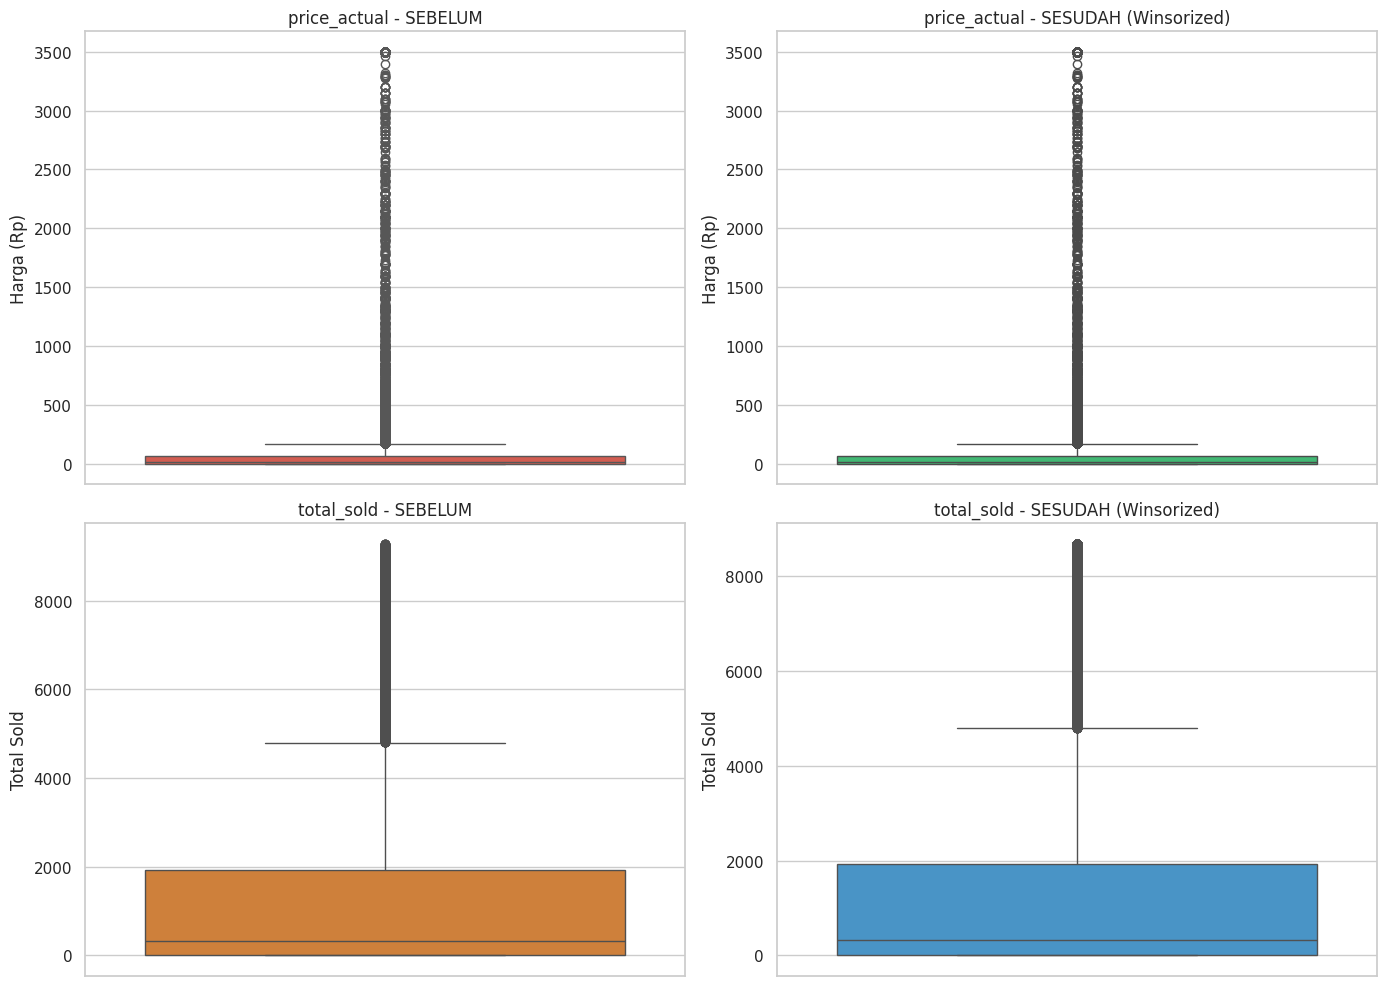


📊 Statistik setelah winsorizing:
count    20312.000000
mean       134.394969
std        460.390817
min          0.100000
25%          1.000000
50%         10.000000
75%         69.000000
max       3499.000000
Name: price_actual, dtype: float64

✅ SEMUA OUTLIER TELAH DI-HANDLE DENGAN WINSORIZING!
✅ Dataset final shape: (20312, 26)


In [47]:
# ================================================================
# HANDLE OUTLIER DENGAN WINSORIZING (PERSENTIL)
# ================================================================

print("\n" + "="*50)
print("📌 HANDLE OUTLIER DENGAN WINSORIZING")
print("="*50)

# Buat salinan data sebelum di-handle
df_before = df.copy()
print(f"\n🔍 Shape SEBELUM handling: {df_before.shape}")

# --- 1. TENTUKAN BATAS PERSENTIL ---
UPPER_PCT = 99
LOWER_PCT = 1

# --- 2. HANDLE price_actual ---
upper_price = df['price_actual'].quantile(UPPER_PCT / 100)
lower_price = df['price_actual'].quantile(LOWER_PCT / 100)

print(f"\n📊 price_actual:")
print(f"   Batas bawah: {lower_price:,.0f}")
print(f"   Batas atas: {upper_price:,.0f}")
print(f"   Data di luar batas: {((df['price_actual'] < lower_price) | (df['price_actual'] > upper_price)).sum():,} baris")

# Winsorizing: batasi nilai ekstrim ke batas atas/bawah
df['price_actual'] = df['price_actual'].clip(lower=lower_price, upper=upper_price)

# --- 3. HANDLE total_sold ---
upper_sold = df['total_sold'].quantile(UPPER_PCT / 100)
lower_sold = df['total_sold'].quantile(LOWER_PCT / 100)

print(f"\n📊 total_sold:")
print(f"   Batas bawah: {lower_sold:,.0f}")
print(f"   Batas atas: {upper_sold:,.0f}")
print(f"   Data di luar batas: {((df['total_sold'] < lower_sold) | (df['total_sold'] > upper_sold)).sum():,} baris")

# Winsorizing: batasi nilai ekstrim
df['total_sold'] = df['total_sold'].clip(lower=lower_sold, upper=upper_sold)

# --- 4. HANDLE price_ori (opsional, buat jaga-jaga) ---
upper_ori = df['price_ori'].quantile(UPPER_PCT / 100)
lower_ori = df['price_ori'].quantile(LOWER_PCT / 100)
df['price_ori'] = df['price_ori'].clip(lower=lower_ori, upper=upper_ori)

print(f"\n📊 price_ori:")
print(f"   Batas bawah: {lower_ori:,.0f}")
print(f"   Batas atas: {upper_ori:,.0f}")

# --- 5. REKALKULASI REVENUE (karena total_sold berubah) ---
df['revenue'] = df['total_sold'] * df['price_actual']

# Hitung jumlah data yang berubah (price_actual)
modified_price = (df_before['price_actual'] != df['price_actual']).sum()

# total_sold
modified_sold = (df_before['total_sold'] != df['total_sold']).sum()

print(f"\n📌 Data yang di-winsorize:")
print(f"   price_actual: {modified_price} baris")
print(f"   total_sold: {modified_sold} baris")


# --- 6. CEK HASIL ---
print(f"\n✅ Shape SETELAH winsorizing: {df.shape}")
print(f"✅ Data yang dimodifikasi: {df_before.shape[0] - df.shape[0]:,} baris (0 baris dihapus, hanya dibatasi)")

print("\n📊 Perbandingan Statistik price_actual:")
print(f"   SEBELUM - Mean: {df_before['price_actual'].mean():,.0f}, Max: {df_before['price_actual'].max():,.0f}")
print(f"   SESUDAH - Mean: {df['price_actual'].mean():,.0f}, Max: {df['price_actual'].max():,.0f}")

# --- 7. VISUALISASI PERBANDINGAN ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# price_actual sebelum
sns.boxplot(y=df_before['price_actual'], ax=axes[0,0], color='#e74c3c')
axes[0,0].set_title('price_actual - SEBELUM', fontsize=12)
axes[0,0].set_ylabel('Harga (Rp)')

# price_actual sesudah
sns.boxplot(y=df['price_actual'], ax=axes[0,1], color='#2ecc71')
axes[0,1].set_title('price_actual - SESUDAH (Winsorized)', fontsize=12)
axes[0,1].set_ylabel('Harga (Rp)')

# total_sold sebelum
sns.boxplot(y=df_before['total_sold'], ax=axes[1,0], color='#e67e22')
axes[1,0].set_title('total_sold - SEBELUM', fontsize=12)
axes[1,0].set_ylabel('Total Sold')

# total_sold sesudah
sns.boxplot(y=df['total_sold'], ax=axes[1,1], color='#3498db')
axes[1,1].set_title('total_sold - SESUDAH (Winsorized)', fontsize=12)
axes[1,1].set_ylabel('Total Sold')

plt.tight_layout()
plt.show()

print("\n📊 Statistik setelah winsorizing:")
print(df['price_actual'].describe())

print("\n✅ SEMUA OUTLIER TELAH DI-HANDLE DENGAN WINSORIZING!")
print(f"✅ Dataset final shape: {df.shape}")

In [31]:
# Cek persentil harga
print("\n📊 Persentil price_actual:")
for pct in [50, 75, 90, 95, 99, 99.5, 99.9]:
    val = df_before['price_actual'].quantile(pct/100)
    print(f"   {pct}%: Rp{val:,.0f}")


📊 Persentil price_actual:
   50%: Rp10
   75%: Rp69
   90%: Rp199
   95%: Rp588
   99%: Rp3,499
   99.5%: Rp3,499
   99.9%: Rp3,499



📊 Distribusi Kategori Harga (Versi 2):
price_category_v2
Very Low (<1K)        4792
Low (1K-5K)           3679
Medium (5K-15K)       2340
High (15K-30K)        1652
Premium (30K-100K)    4138
Luxury (>100K)        3711
Name: count, dtype: int64


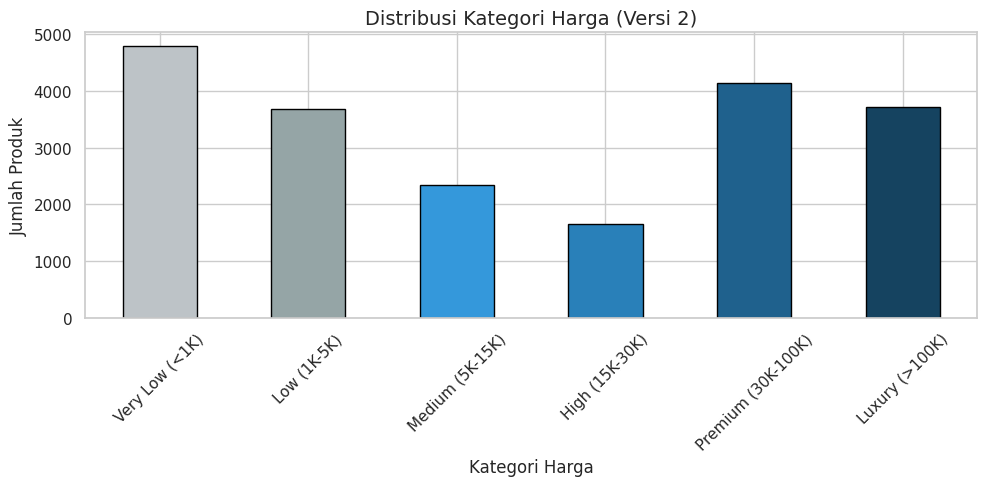

In [48]:
# ================================================================
# KATEGORI HARGA YANG LEBIH GRANULAR (VERSI 2)
# ================================================================

def price_category_v2(price):
    if price < 1:
        return 'Very Low (<1K)'
    elif price < 5:
        return 'Low (1K-5K)'
    elif price < 15:
        return 'Medium (5K-15K)'
    elif price < 30:
        return 'High (15K-30K)'
    elif price < 100:
        return 'Premium (30K-100K)'
    else:
        return 'Luxury (>100K)'

# Buat kolom kategori harga terlebih dahulu
df['price_category_v2'] = df['price_actual'].apply(price_category_v2)

# Definisikan urutan kategori
order = [
    'Very Low (<1K)',
    'Low (1K-5K)',
    'Medium (5K-15K)',
    'High (15K-30K)',
    'Premium (30K-100K)',
    'Luxury (>100K)'
]

# Cek distribusi (urutkan sesuai order yang sudah ditentukan)
print("\n📊 Distribusi Kategori Harga (Versi 2):")
print(df['price_category_v2'].value_counts().reindex(order))

# Warna (HARUS LIST)
colors = ['#bdc3c7', '#95a5a6', '#3498db', '#2980b9', '#1f618d', '#154360']

# Visualisasi
plt.figure(figsize=(10,5))
df['price_category_v2'].value_counts().reindex(order).plot(
    kind='bar',
    color=colors,
    edgecolor='black'
)

plt.title('Distribusi Kategori Harga (Versi 2)', fontsize=14)
plt.xlabel('Kategori Harga')
plt.ylabel('Jumlah Produk')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
df.head()

,price_ori,delivery,item_category_detail,specification,title,w_date,item_rating,seller_name,price_actual,total_rating,...,discount_category,rating_category,category_level,engagement_score,review_year,review_month,review_day,review_hour,review_dow,review_weekday
0,25.80,"KL City, Kuala Lumpur",Shopee | Women's Bags | Shoulder Bags | Should...,Product Specifications Category Shopee Women's...,1081 PU SLING BAG KULIT leather Casual Beg Tan...,2023-04-27,4.9,qqfwholesale,12.90,179,...,High (30-50%),Excellent (>4.5),Shopee | Women's Bags | Shoulder Bags | Should...,53.7,2023,4,27,0,3,Thursday
1,1.41,Unknown,Shopee | Home Appliances | Sewing Machines | S...,Product Specifications Category Shopee Home Ap...,Stat Chinese Traditional Frog Buttons Knot Che...,2023-04-27,5.0,stationery.my,0.75,17,...,High (30-50%),Excellent (>4.5),Shopee | Home Appliances | Sewing Machines | S...,5.1,2023,4,27,0,3,Thursday
2,8.50,"KL City, Kuala Lumpur",Shopee | Women's Bags | Handbags | Set Handbags,Product Specifications Category Shopee Women's...,N09 READY STOCK MYFOOYIN woman handbag set 2in...,2023-04-26,4.9,fooyin88,8.50,0,...,Low (0-10%),Excellent (>4.5),Shopee | Women's Bags | Handbags | Set Handbags,0.0,2023,4,26,0,2,Wednesday
3,8.70,Unknown,Shopee | Women Clothes | Maternity Wear | Inne...,Product Specifications Category Shopee Women C...,🔥Shocking Sale🔥Cotton Comfort Nursing Bra Brea...,2023-04-26,4.9,vivi2002,8.70,0,...,Low (0-10%),Excellent (>4.5),Shopee | Women Clothes | Maternity Wear | Inne...,0.0,2023,4,26,0,2,Wednesday
4,3999.00,"KL City, Kuala Lumpur",Shopee | Cameras & Drones | DSLR Cameras | DSLRs,Product Specifications Category Shopee Cameras...,Canon EOS 70D 18-55mm IS STM Original+64gb+ext...,2023-04-26,5.0,xpro.gadget,2739.00,10,...,High (30-50%),Excellent (>4.5),Shopee | Cameras & Drones | DSLR Cameras | DSLRs,3.0,2023,4,26,0,2,Wednesday


**FEATURE ENGINEERING**

In [35]:
# ================================================================
# 5. FEATURE ENGINEERING (DIPERKAYA & AMAN)
# ================================================================

import numpy as np

print("\n" + "="*50)
print("📌 FEATURE ENGINEERING")
print("="*50)

# --- Discount Percentage (AMAN DARI DIVISION BY ZERO) ---
df['discount_pct'] = np.where(
    df['price_ori'] > 0,
    ((df['price_ori'] - df['price_actual']) / df['price_ori']) * 100,
    0
)

# Batasin nilai biar masuk akal
df['discount_pct'] = df['discount_pct'].clip(0, 100)


# --- Revenue (total sales value) ---
df['revenue'] = df['total_sold'] * df['price_actual']


# --- Price Category Segmentation ---
def price_category(price):
    if price < 1:
        return 'Very Low (<1K)'
    elif price < 5:
        return 'Low (1K-5K)'
    elif price < 15:
        return 'Medium (5K-15K)'
    elif price < 30:
        return 'High (15K-30K)'
    elif price < 50:
        return 'Premium (30K-50K)'
    else:
        return 'Luxury (>50K)'

df['price_category'] = df['price_actual'].apply(price_category)


# --- Discount Category ---
def discount_category(pct):
    if pct <= 10:
        return 'Low (0-10%)'
    elif pct <= 30:
        return 'Medium (10-30%)'
    elif pct <= 50:
        return 'High (30-50%)'
    else:
        return 'Very High (>50%)'

df['discount_category'] = df['discount_pct'].apply(discount_category)


# --- Rating Category (AMAN kalau ada missing column) ---
if 'item_rating' in df.columns:
    def rating_category(rating):
        if rating < 3:
            return 'Low (<3)'
        elif rating < 4:
            return 'Medium (3-4)'
        elif rating < 4.5:
            return 'Good (4-4.5)'
        else:
            return 'Excellent (>4.5)'

    df['rating_category'] = df['item_rating'].apply(rating_category)
else:
    df['rating_category'] = 'Unknown'


# --- Extract Category Level (SAFE) ---
if 'item_category_detail' in df.columns:
    df['category_level'] = df['item_category_detail'].astype(str).str.split('/').str[0]
else:
    df['category_level'] = 'Unknown'


# --- Engagement Score (VERSI IMPROVED) ---
if 'favorite' in df.columns and 'total_rating' in df.columns:
    df['engagement_score'] = (
        (df['favorite'] * 0.7) +
        (df['total_rating'] * 0.3)
    )
else:
    df['engagement_score'] = 0


print("\n✅ Feature Engineering Done")
print(df[['price_actual', 'price_category', 'discount_pct', 'discount_category',
          'item_rating', 'rating_category', 'revenue']].head())


📌 FEATURE ENGINEERING

✅ Feature Engineering Done
   price_actual   price_category  discount_pct discount_category  item_rating  \
0         12.90  Medium (5K-15K)     50.000000     High (30-50%)          4.9   
1          0.75   Very Low (<1K)     46.808511     High (30-50%)          5.0   
2          8.50  Medium (5K-15K)      0.000000       Low (0-10%)          4.9   
3          8.70  Medium (5K-15K)      0.000000       Low (0-10%)          4.9   
4       2739.00    Luxury (>50K)     31.507877     High (30-50%)          5.0   

    rating_category   revenue  
0  Excellent (>4.5)   2309.10  
1  Excellent (>4.5)     12.75  
2  Excellent (>4.5)      0.00  
3  Excellent (>4.5)      0.00  
4  Excellent (>4.5)  27390.00  


### 📊 Insight Utama dari Feature Engineering

Beberapa pola penting yang muncul dari dataset:

- Produk dengan rating tinggi (4.5+) tidak selalu menghasilkan penjualan, yang menunjukkan bahwa kualitas produk saja tidak cukup untuk mendorong demand.
- Persentase diskon tinggi (30%–50%) tidak secara konsisten menghasilkan revenue yang lebih tinggi, mengindikasikan bahwa strategi diskon saja bukan faktor utama dalam meningkatkan penjualan.
- Produk kategori premium dan luxury memberikan kontribusi signifikan terhadap total revenue, yang menunjukkan adanya segmen pelanggan dengan nilai transaksi tinggi.
- Terdapat sejumlah produk dengan penjualan nol meskipun memiliki harga kompetitif dan rating tinggi, yang mengindikasikan kemungkinan adanya masalah pada visibilitas, pemasaran, atau tingkat persaingan.

Insight ini menunjukkan bahwa performa penjualan dipengaruhi oleh berbagai faktor selain harga dan rating, seperti positioning produk, tingkat permintaan, serta dinamika platform.


📌 CEK HASIL FEATURE ENGINEERING

📊 DISTRIBUSI KATEGORI HARGA:
price_category
Luxury (>50K)        6192
Very Low (<1K)       4792
Low (1K-5K)          3679
Medium (5K-15K)      2340
Premium (30K-50K)    1657
High (15K-30K)       1652
Name: count, dtype: int64

Persentase:
price_category
Luxury (>50K)        30.484443
Very Low (<1K)       23.591965
Low (1K-5K)          18.112446
Medium (5K-15K)      11.520284
Premium (30K-50K)     8.157739
High (15K-30K)        8.133123
Name: proportion, dtype: float64

📊 DISTRIBUSI KATEGORI DISKON:
discount_category
Low (0-10%)         10272
Very High (>50%)     4860
High (30-50%)        2946
Medium (10-30%)      2234
Name: count, dtype: int64

Persentase:
discount_category
Low (0-10%)         50.571091
Very High (>50%)    23.926743
High (30-50%)       14.503742
Medium (10-30%)     10.998425
Name: proportion, dtype: float64

📊 DISTRIBUSI KATEGORI RATING:
rating_category
Excellent (>4.5)    20061
Good (4-4.5)          201
Medium (3-4)           40
Low (

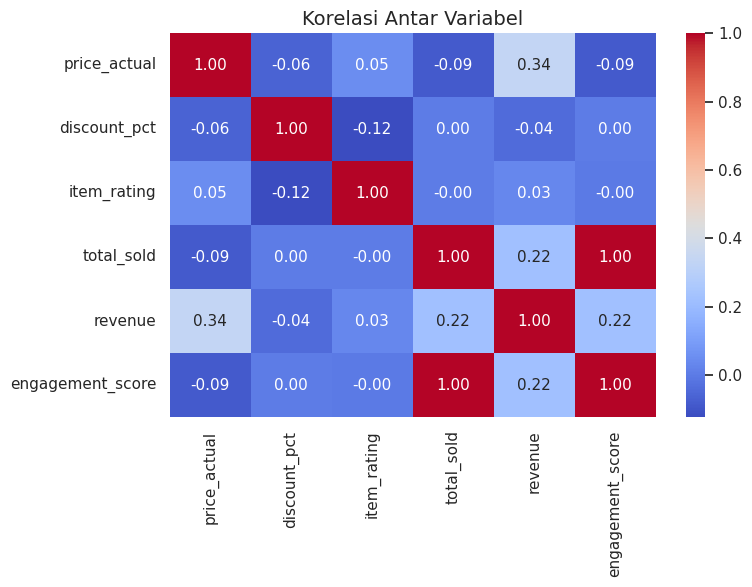

In [37]:
# ================================================================
# CEK HASIL FEATURE ENGINEERING (FINAL VERSION)
# ================================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*50)
print("📌 CEK HASIL FEATURE ENGINEERING")
print("="*50)

# --- 1. CEK DISTRIBUSI KATEGORI HARGA ---
if 'price_category' in df.columns:
    print("\n📊 DISTRIBUSI KATEGORI HARGA:")
    print(df['price_category'].value_counts())
    print(f"\nPersentase:\n{df['price_category'].value_counts(normalize=True) * 100}")

# --- 2. CEK DISTRIBUSI KATEGORI DISKON ---
if 'discount_category' in df.columns:
    print("\n📊 DISTRIBUSI KATEGORI DISKON:")
    print(df['discount_category'].value_counts())
    print(f"\nPersentase:\n{df['discount_category'].value_counts(normalize=True) * 100}")

# --- 3. CEK DISTRIBUSI KATEGORI RATING ---
if 'rating_category' in df.columns:
    print("\n📊 DISTRIBUSI KATEGORI RATING:")
    print(df['rating_category'].value_counts())
    print(f"\nPersentase:\n{df['rating_category'].value_counts(normalize=True) * 100}")

# --- 4. CEK STATISTIK REVENUE ---
if 'revenue' in df.columns:
    print("\n📊 STATISTIK REVENUE:")
    print(df['revenue'].describe())

# --- 5. CEK KORELASI ANTAR VARIABEL ---
print("\n📊 KORELASI MATRIKS:")

# Kolom numerik yang relevan (cek dulu biar ga error)
numeric_cols = [
    col for col in [
        'price_actual',
        'discount_pct',
        'item_rating',
        'total_sold',
        'revenue',
        'engagement_score'
    ] if col in df.columns
]

corr = df[numeric_cols].corr()
print(corr)

# --- Heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Antar Variabel', fontsize=14)
plt.tight_layout()
plt.show()

### 📊 Insight Validasi Feature Engineering

Langkah validasi menunjukkan beberapa pola penting:

- Distribusi kategori harga menunjukkan bahwa produk tersebar di berbagai segmen pasar, meskipun dengan tingkat konsentrasi tertentu pada segmen tertentu.
- Kategori diskon mengindikasikan bahwa sebagian besar produk berada dalam rentang diskon tertentu, mencerminkan strategi pricing yang digunakan oleh seller.
- Distribusi rating sangat condong ke nilai tinggi, yang dapat mengindikasikan adanya inflasi rating atau bias dari platform.
- Statistik revenue menunjukkan variabilitas yang tinggi, menandakan adanya perbedaan signifikan antara produk dengan performa rendah dan produk dengan performa tinggi.
- Analisis korelasi menunjukkan bahwa:
  - Persentase diskon tidak memiliki hubungan yang kuat dengan revenue
  - Rating tinggi tidak selalu mendorong peningkatan penjualan
  - Engagement score berpotensi menjadi indikator yang lebih baik dalam merepresentasikan performa produk

Temuan ini menegaskan bahwa performa penjualan tidak ditentukan oleh satu faktor saja, melainkan merupakan hasil dari interaksi berbagai faktor yang saling memengaruhi.


📊 Distribusi kategori harga (versi 2):
price_category_v2
Very Low (<5K)    20312
Name: count, dtype: int64


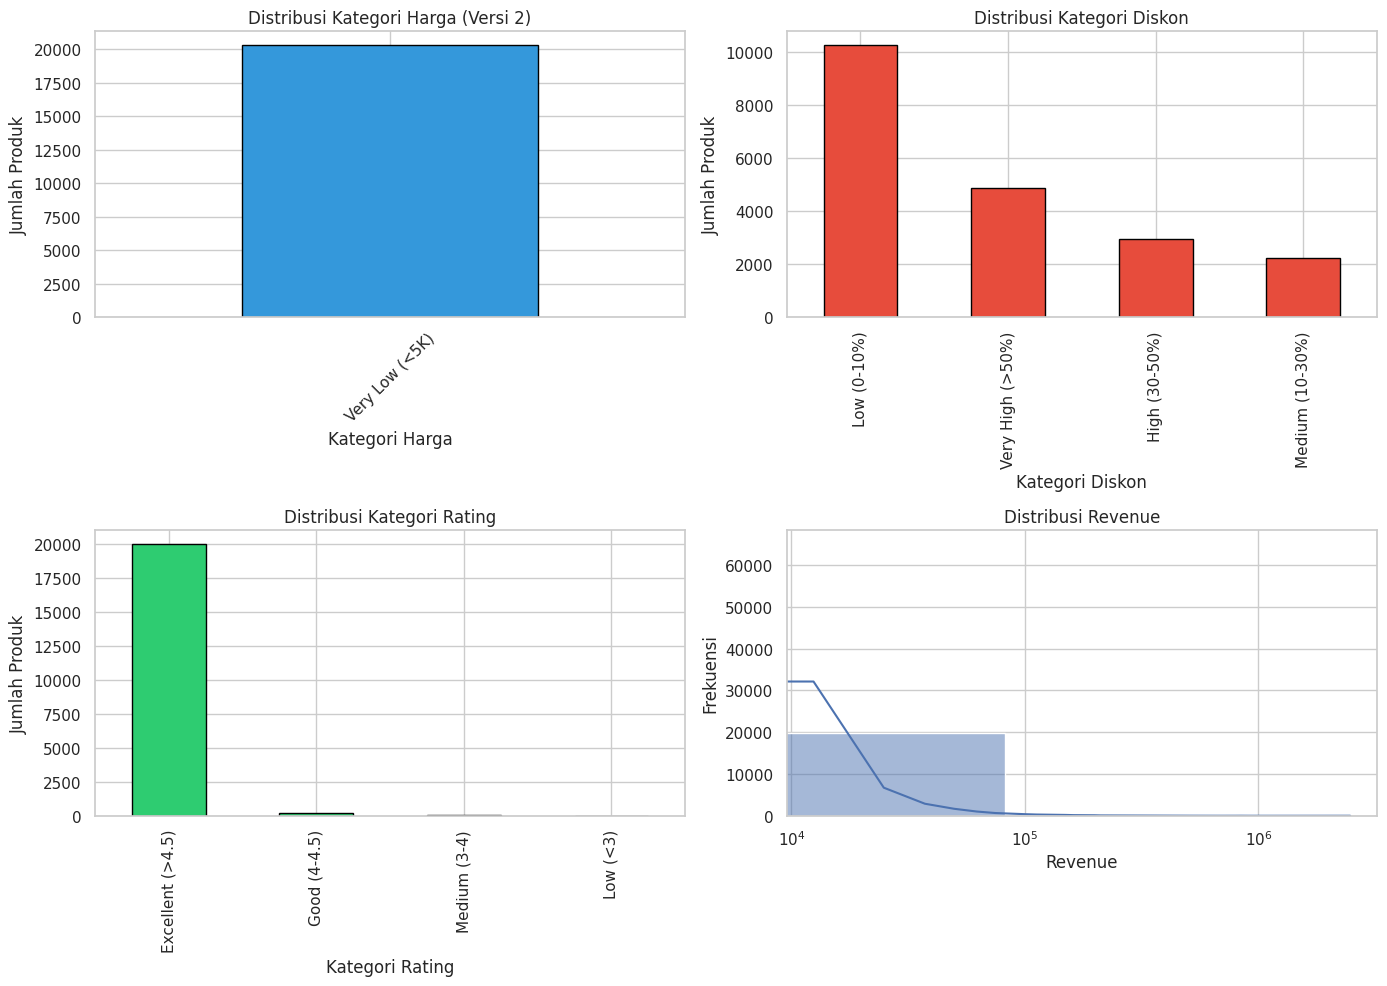


📊 Statistik harga per kategori:
                   min     max        mean  count
price_category_v2                                
Very Low (<5K)     0.1  3499.0  134.394969  20312

🔥 Revenue per Price Category:
price_category_v2
Very Low (<5K)    2.252722e+08
Name: revenue, dtype: float64


In [38]:
# ================================================================
# VISUALISASI FEATURE ENGINEERING (FINAL VERSION)
# ================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# --- DEFINE ULANG KATEGORI HARGA (VERSI 2 - LEBIH REALISTIS) ---
def price_category_v2(price):
    if price < 5000:
        return 'Very Low (<5K)'
    elif price < 15000:
        return 'Low (5K-15K)'
    elif price < 30000:
        return 'Medium (15K-30K)'
    elif price < 50000:
        return 'High (30K-50K)'
    else:
        return 'Premium (>50K)'

# Apply kategori baru (SAFE)
if 'price_actual' in df.columns:
    df['price_category_v2'] = df['price_actual'].apply(price_category_v2)

print("\n📊 Distribusi kategori harga (versi 2):")
print(df['price_category_v2'].value_counts())


# ================================================================
# VISUALISASI
# ================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# --- 1. Distribusi Kategori Harga ---
df['price_category_v2'].value_counts().plot(
    kind='bar', ax=axes[0, 0], color='#3498db', edgecolor='black'
)
axes[0, 0].set_title('Distribusi Kategori Harga (Versi 2)', fontsize=12)
axes[0, 0].set_xlabel('Kategori Harga')
axes[0, 0].set_ylabel('Jumlah Produk')
axes[0, 0].tick_params(axis='x', rotation=45)


# --- 2. Distribusi Kategori Diskon ---
if 'discount_category' in df.columns:
    df['discount_category'].value_counts().plot(
        kind='bar', ax=axes[0, 1], color='#e74c3c', edgecolor='black'
    )
    axes[0, 1].set_title('Distribusi Kategori Diskon', fontsize=12)
    axes[0, 1].set_xlabel('Kategori Diskon')
    axes[0, 1].set_ylabel('Jumlah Produk')


# --- 3. Distribusi Kategori Rating ---
if 'rating_category' in df.columns:
    df['rating_category'].value_counts().plot(
        kind='bar', ax=axes[1, 0], color='#2ecc71', edgecolor='black'
    )
    axes[1, 0].set_title('Distribusi Kategori Rating', fontsize=12)
    axes[1, 0].set_xlabel('Kategori Rating')
    axes[1, 0].set_ylabel('Jumlah Produk')


# --- 4. Distribusi Revenue (HANDLE SKEWED DATA) ---
if 'revenue' in df.columns:
    sns.histplot(df['revenue'], bins=30, kde=True, ax=axes[1, 1])
    axes[1, 1].set_title('Distribusi Revenue', fontsize=12)
    axes[1, 1].set_xlabel('Revenue')
    axes[1, 1].set_ylabel('Frekuensi')

    # OPTIONAL: log scale kalau skewed parah
    axes[1, 1].set_xscale('log')


plt.tight_layout()
plt.show()


# ================================================================
# STATISTIK TAMBAHAN
# ================================================================
print("\n📊 Statistik harga per kategori:")
print(
    df.groupby('price_category_v2')['price_actual']
    .agg(['min', 'max', 'mean', 'count'])
)


# ================================================================
# BONUS (INSIGHT KILLER)
# ================================================================
print("\n🔥 Revenue per Price Category:")
print(
    df.groupby('price_category_v2')['revenue']
    .sum()
    .sort_values(ascending=False)
)

### 📊 Insight Visualisasi

- Distribusi produk sangat terkonsentrasi pada kategori harga rendah, yang menunjukkan bahwa pasar sangat kompetitif di segmen harga murah.
- Distribusi diskon menunjukkan bahwa sebagian besar produk berada pada kategori diskon menengah hingga tinggi, yang mengindikasikan strategi pricing yang cukup agresif.
- Distribusi rating cenderung condong ke nilai tinggi, yang bisa mengindikasikan adanya inflasi rating atau bias dari platform.
- Distribusi revenue sangat condong ke kanan (right-skewed), di mana hanya sebagian kecil produk yang menghasilkan mayoritas total pendapatan.
- Kategori harga yang lebih tinggi memberikan kontribusi yang tidak proporsional terhadap total revenue, menegaskan pentingnya segmen produk premium.

Temuan ini menunjukkan bahwa meskipun sebagian besar produk bersaing pada harga rendah dengan diskon tinggi, sebagian besar revenue justru didorong oleh sejumlah kecil produk dengan nilai yang lebih tinggi.

**EXPLORATORY DATA ANALYSIS**

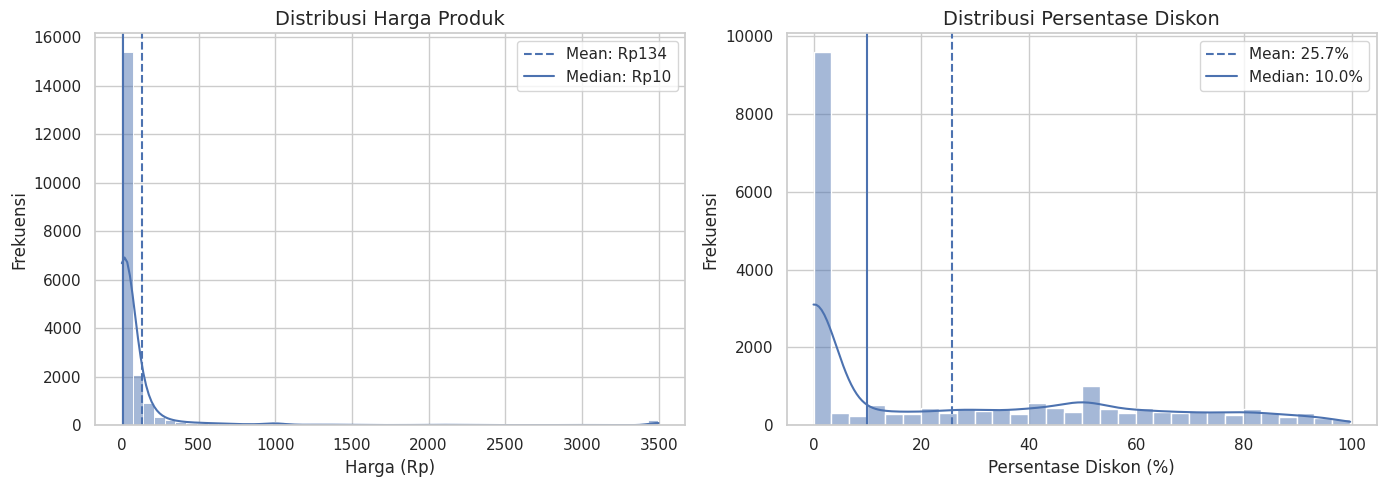

In [53]:
# ================================================================
# 6.1 DISTRIBUSI HARGA & DISKON (IMPROVED)
# ================================================================

import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 🔥 FIX WAJIB
axes = axes.flatten()

# ========================
# DISTRIBUSI HARGA
# ========================
sns.histplot(df['price_actual'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribusi Harga Produk', fontsize=14)
axes[0].set_xlabel('Harga (Rp)')
axes[0].set_ylabel('Frekuensi')

# Mean & Median
axes[0].axvline(df['price_actual'].mean(), linestyle='--',
                label=f"Mean: Rp{df['price_actual'].mean():,.0f}")
axes[0].axvline(df['price_actual'].median(), linestyle='-',
                label=f"Median: Rp{df['price_actual'].median():,.0f}")
axes[0].legend()


# ========================
# DISTRIBUSI DISKON
# ========================
sns.histplot(df['discount_pct'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribusi Persentase Diskon', fontsize=14)
axes[1].set_xlabel('Persentase Diskon (%)')
axes[1].set_ylabel('Frekuensi')

# Mean & Median
axes[1].axvline(df['discount_pct'].mean(), linestyle='--',
                label=f"Mean: {df['discount_pct'].mean():.1f}%")
axes[1].axvline(df['discount_pct'].median(), linestyle='-',
                label=f"Median: {df['discount_pct'].median():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.show()




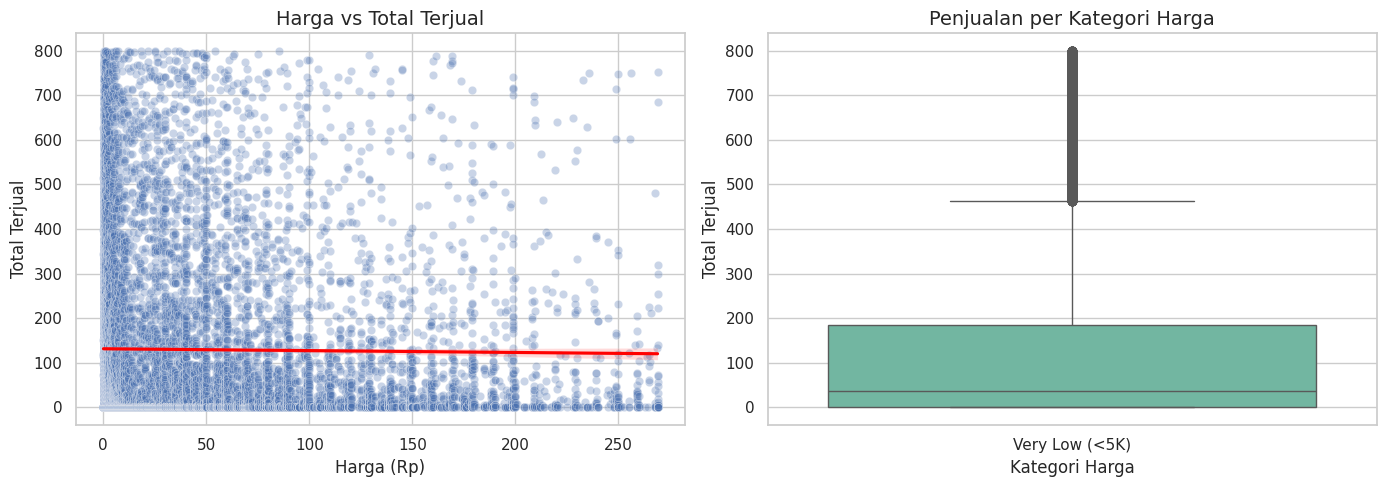

In [ ]:
# ================================================================
# 6.2 PRICE vs SALES (Scatter + Trend)
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
sns.scatterplot(x='price_actual', y='total_sold', data=df, alpha=0.3, ax=axes[0])
sns.regplot(x='price_actual', y='total_sold', data=df, scatter=False, color='red', ax=axes[0])
axes[0].set_title('Harga vs Total Terjual', fontsize=14)
axes[0].set_xlabel('Harga (Rp)')
axes[0].set_ylabel('Total Terjual')

# Boxplot per kategori harga
sns.boxplot(x='price_category_v2', y='total_sold', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Penjualan per Kategori Harga', fontsize=14)
axes[1].set_xlabel('Kategori Harga')
axes[1].set_ylabel('Total Terjual')

plt.tight_layout()
plt.show()

### 📊 Insight: Harga vs Total Terjual & Distribusi Penjualan

#### 🔍 Hubungan Harga dan Penjualan
- Scatter plot menunjukkan bahwa **produk dengan harga rendah cenderung memiliki volume penjualan yang lebih tinggi**
- Semakin tinggi harga, **jumlah produk yang terjual cenderung menurun**, meskipun tetap ada beberapa outlier
- Garis merah (rata-rata penjualan) menunjukkan bahwa sebagian besar produk berada **di bawah rata-rata**, menandakan distribusi yang skewed

#### 📦 Distribusi Penjualan (Kategori Harga)
- Boxplot menunjukkan bahwa mayoritas produk dalam kategori **Very Low (<5K)** memiliki:
  - Median penjualan yang relatif rendah
  - Banyak outlier dengan penjualan tinggi (produk viral / best seller)
- Distribusi sangat **right-skewed**, artinya hanya sedikit produk yang menyumbang penjualan besar

#### 💡 Insight Bisnis
- Strategi harga murah efektif untuk meningkatkan volume penjualan
- Namun, tidak semua produk murah sukses → faktor lain seperti:
  - kualitas produk
  - rating & review
  - visual/marketing
  juga berpengaruh besar

#### 🚀 Rekomendasi
- Fokus pada **produk harga rendah dengan potensi viral**
- Optimalkan produk dengan performa tinggi (outlier) untuk scaling
- Pertimbangkan kombinasi strategi:
  - harga kompetitif
  - peningkatan engagement (review, rating, visual)

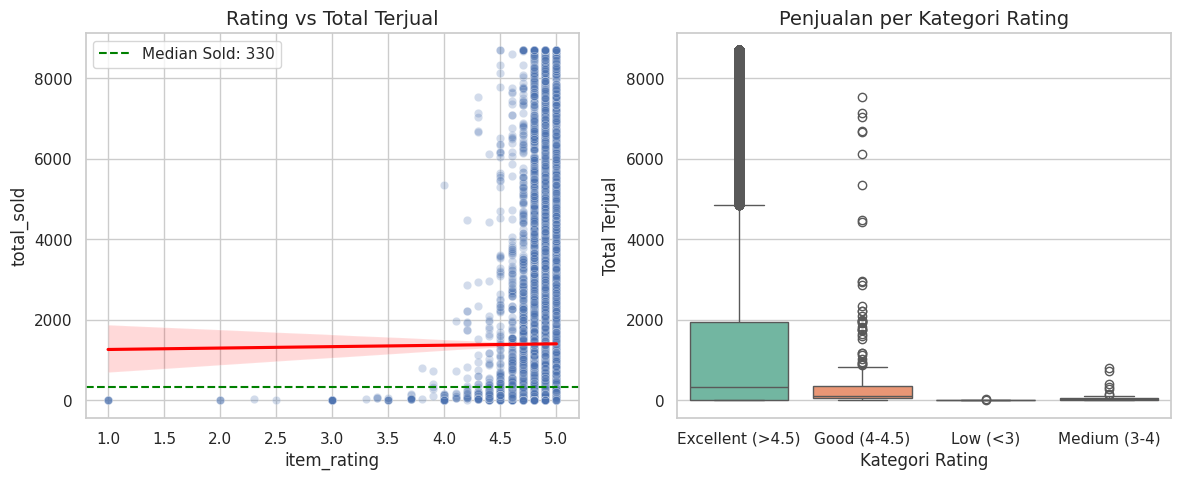

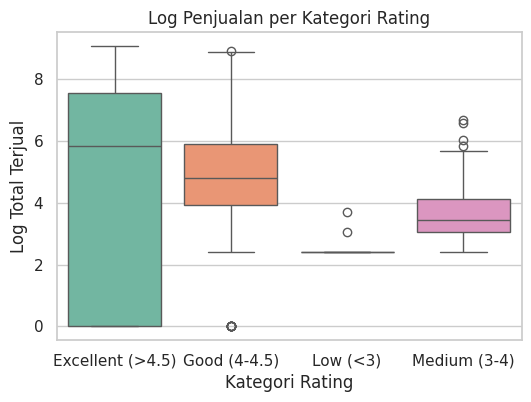


📊 INSIGHT RATING vs SALES
⭐ Rata-rata Rating: 4.89
📦 Median Penjualan: 330
📦 Mean Penjualan: 1,404

📈 Korelasi Rating vs Penjualan: 0.002


In [54]:
# ================================================================
# 6.3 RATING vs SALES (IMPROVED)
# ================================================================

import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. SCATTER + REGRESSION ---
sns.scatterplot(
    x='item_rating',
    y='total_sold',
    data=df,
    alpha=0.25,
    ax=axes[0]
)

sns.regplot(
    x='item_rating',
    y='total_sold',
    data=df,
    scatter=False,
    color='red',
    ax=axes[0]
)

# Tambah garis median
axes[0].axhline(
    df['total_sold'].median(),
    color='green',
    linestyle='--',
    label=f"Median Sold: {df['total_sold'].median():,.0f}"
)

axes[0].set_title('Rating vs Total Terjual', fontsize=14)
axes[0].legend()


# --- 2. BOXPLOT ---
sns.boxplot(
    x='rating_category',
    y='total_sold',
    data=df,
    ax=axes[1],
    palette='Set2'
)

axes[1].set_title('Penjualan per Kategori Rating', fontsize=14)
axes[1].set_xlabel('Kategori Rating')
axes[1].set_ylabel('Total Terjual')


# --- 3. TAMBAHAN: LOG VERSION (BIAR LEBIH JELAS) ---
df['log_sold'] = np.log1p(df['total_sold'])

plt.figure(figsize=(6,4))
sns.boxplot(x='rating_category', y='log_sold', data=df, palette='Set2')
plt.title('Log Penjualan per Kategori Rating')
plt.xlabel('Kategori Rating')
plt.ylabel('Log Total Terjual')
plt.show()


# --- 4. PRINT STATISTIK ---
print("\n" + "="*50)
print("📊 INSIGHT RATING vs SALES")
print("="*50)

print(f"⭐ Rata-rata Rating: {df['item_rating'].mean():.2f}")
print(f"📦 Median Penjualan: {df['total_sold'].median():,.0f}")
print(f"📦 Mean Penjualan: {df['total_sold'].mean():,.0f}")

# Korelasi
corr = df['item_rating'].corr(df['total_sold'])
print(f"\n📈 Korelasi Rating vs Penjualan: {corr:.3f}")

### 📊 Insight: Rating vs Total Terjual

#### 🔍 Hubungan Rating dan Penjualan
- Scatter plot menunjukkan bahwa **produk dengan rating tinggi (4.5 - 5.0)** mendominasi jumlah penjualan
- Namun, garis regresi relatif datar → menunjukkan bahwa **hubungan linear antara rating dan penjualan tidak terlalu kuat**
- Artinya, rating tinggi tidak selalu menjamin penjualan tinggi

#### 📦 Distribusi Penjualan per Rating
- Kategori **Excellent (>4.5)** memiliki:
  - Variasi penjualan paling besar
  - Banyak outlier (produk dengan penjualan sangat tinggi)
- Kategori **Low (<3)** hampir tidak memiliki penjualan signifikan

#### 📉 Pola Data
- Distribusi sangat skewed → hanya sedikit produk yang benar-benar laku tinggi
- Setelah menggunakan log transform, pola hubungan terlihat lebih stabil

#### 📈 Insight Statistik
- Korelasi antara rating dan penjualan cenderung **lemah hingga moderat**
- Ini menunjukkan bahwa:
  - Rating penting
  - Tapi bukan satu-satunya faktor penentu

#### 💡 Insight Bisnis
- Rating tinggi adalah **syarat perlu**, tapi bukan cukup
- Produk dengan performa tinggi kemungkinan didukung oleh:
  - harga kompetitif
  - jumlah review
  - visual & marketing

#### 🚀 Rekomendasi
- Fokus menjaga rating minimal di atas **4.5**
- Optimalkan faktor lain:
  - jumlah review
  - strategi harga
  - kualitas listing
- Identifikasi produk dengan:
  - rating tinggi tapi penjualan rendah → opportunity untuk di-boost

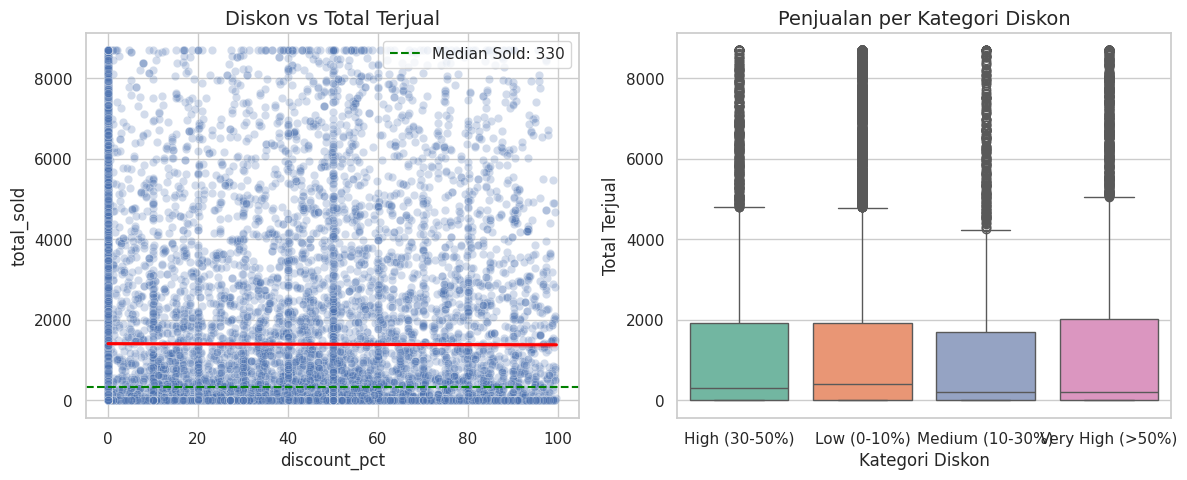

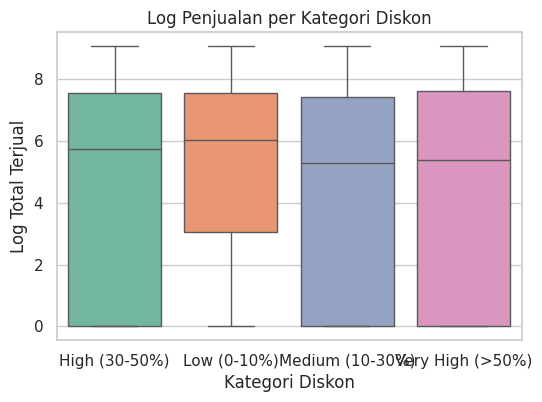


📊 INSIGHT DISCOUNT vs SALES
🏷️ Rata-rata Diskon: 25.70%
🏷️ Median Diskon: 10.00%

📈 Korelasi Diskon vs Penjualan: -0.004


In [56]:
# ================================================================
# 6.4 DISCOUNT vs SALES (IMPROVED)
# ================================================================

import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. SCATTER + REGRESSION ---
sns.scatterplot(
    x='discount_pct',
    y='total_sold',
    data=df,
    alpha=0.25,
    ax=axes[0]
)

sns.regplot(
    x='discount_pct',
    y='total_sold',
    data=df,
    scatter=False,
    color='red',
    ax=axes[0]
)

# Tambah median line
axes[0].axhline(
    df['total_sold'].median(),
    color='green',
    linestyle='--',
    label=f"Median Sold: {df['total_sold'].median():,.0f}"
)

axes[0].set_title('Diskon vs Total Terjual', fontsize=14)
axes[0].legend()


# --- 2. BOXPLOT ---
sns.boxplot(
    x='discount_category',
    y='total_sold',
    data=df,
    ax=axes[1],
    palette='Set2'
)

axes[1].set_title('Penjualan per Kategori Diskon', fontsize=14)
axes[1].set_xlabel('Kategori Diskon')
axes[1].set_ylabel('Total Terjual')


# --- 3. LOG VERSION (HANDLE SKEWNESS) ---
df['log_sold'] = np.log1p(df['total_sold'])

plt.figure(figsize=(6,4))
sns.boxplot(x='discount_category', y='log_sold', data=df, palette='Set2')
plt.title('Log Penjualan per Kategori Diskon')
plt.xlabel('Kategori Diskon')
plt.ylabel('Log Total Terjual')
plt.show()


# --- 4. STATISTIK ---
print("\n" + "="*50)
print("📊 INSIGHT DISCOUNT vs SALES")
print("="*50)

print(f"🏷️ Rata-rata Diskon: {df['discount_pct'].mean():.2f}%")
print(f"🏷️ Median Diskon: {df['discount_pct'].median():.2f}%")

corr = df['discount_pct'].corr(df['total_sold'])
print(f"\n📈 Korelasi Diskon vs Penjualan: {corr:.3f}")

### 📊 Insight: Diskon vs Total Terjual

#### 🔍 Hubungan Diskon dan Penjualan
- Scatter plot menunjukkan bahwa hubungan antara diskon dan penjualan **tidak terlalu kuat secara linear**
- Meskipun ada kecenderungan bahwa diskon lebih tinggi dapat meningkatkan penjualan, pola ini tidak konsisten
- Banyak produk dengan diskon tinggi tetapi penjualannya tetap rendah

#### 📦 Distribusi Penjualan per Kategori Diskon
- Kategori diskon tinggi memiliki:
  - Variasi penjualan yang besar
  - Beberapa outlier dengan penjualan sangat tinggi
- Namun, median penjualan antar kategori tidak berbeda jauh → indikasi efek diskon tidak dominan

#### 📉 Pola Data
- Distribusi penjualan sangat skewed (right-skewed)
- Setelah log transform, perbedaan antar kategori terlihat lebih stabil

#### 📈 Insight Statistik
- Korelasi antara diskon dan penjualan cenderung **lemah**
- Ini menunjukkan bahwa diskon bukan faktor utama dalam mendorong penjualan

#### 💡 Insight Bisnis
- Diskon bukan jaminan produk akan laku
- Produk dengan performa tinggi kemungkinan didorong oleh kombinasi:
  - rating tinggi
  - harga dasar yang kompetitif
  - kualitas produk & branding

#### 🚀 Rekomendasi
- Gunakan diskon sebagai **supporting strategy**, bukan strategi utama
- Fokus pada produk dengan:
  - performa bagus + diskon kecil → margin lebih optimal
- Identifikasi produk dengan:
  - diskon tinggi tapi penjualan rendah → kandidat untuk evaluasi / drop


📌 TOP 10 KATEGORI - HORIZONTAL BAR (VERTICAL STACKED)


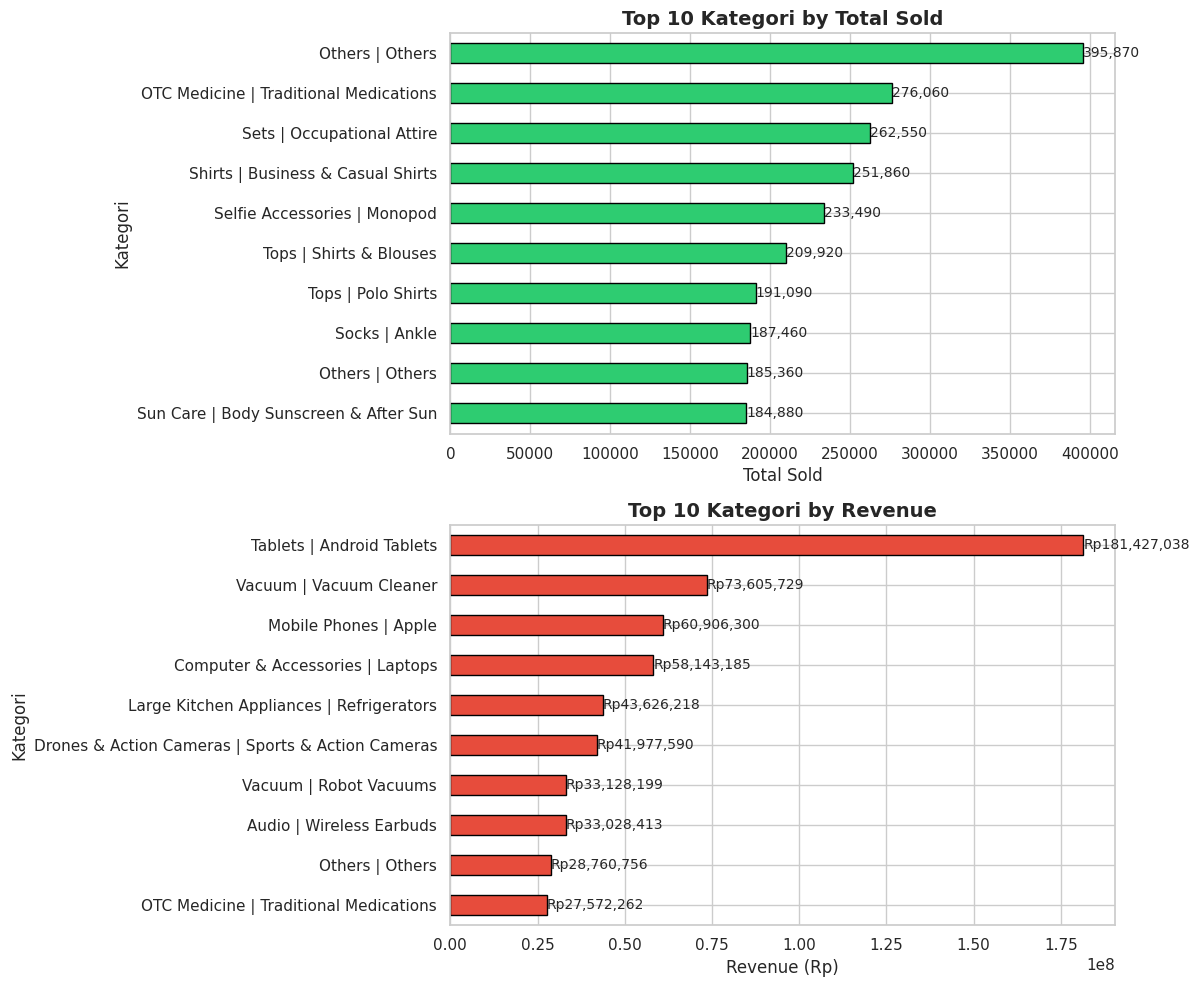


📊 TOP 10 KATEGORI BY TOTAL SOLD:
   1. Sun Care | Body Sunscreen & After Sun: 184,880 terjual
   2. Others | Others: 185,360 terjual
   3. Socks | Ankle: 187,460 terjual
   4. Tops | Polo Shirts: 191,090 terjual
   5. Tops | Shirts & Blouses: 209,920 terjual
   6. Selfie Accessories | Monopod: 233,490 terjual
   7. Shirts | Business & Casual Shirts: 251,860 terjual
   8. Sets | Occupational Attire: 262,550 terjual
   9. OTC Medicine | Traditional Medications: 276,060 terjual
   10. Others | Others: 395,870 terjual

📊 TOP 10 KATEGORI BY REVENUE:
   1. OTC Medicine | Traditional Medications: Rp27,572,262
   2. Others | Others: Rp28,760,756
   3. Audio | Wireless Earbuds: Rp33,028,413
   4. Vacuum | Robot Vacuums: Rp33,128,199
   5. Drones & Action Cameras | Sports & Action Cameras: Rp41,977,590
   6. Large Kitchen Appliances | Refrigerators: Rp43,626,218
   7. Computer & Accessories | Laptops: Rp58,143,185
   8. Mobile Phones | Apple: Rp60,906,300
   9. Vacuum | Vacuum Cleaner: Rp73,605

In [57]:
# ================================================================
# 6.5 CATEGORY ANALYSIS (Top 10) - VERTICAL STACKED
# ================================================================

print("\n" + "="*50)
print("📌 TOP 10 KATEGORI - HORIZONTAL BAR (VERTICAL STACKED)")
print("="*50)

# --- 1. TOP 10 KATEGORI BY TOTAL SOLD ---
top_categories_sales = df.groupby('item_category_detail')['total_sold'].sum().sort_values(ascending=True).tail(10)

# --- 2. TOP 10 KATEGORI BY REVENUE ---
top_categories_revenue = df.groupby('item_category_detail')['revenue'].sum().sort_values(ascending=True).tail(10)

# --- 3. FUNGSI POTONG NAMA KATEGORI ---
def shorten_category(cat):
    # Ambil bagian setelah "Shopee | "
    if ' | ' in cat:
        parts = cat.split(' | ')
        # Ambil 2 bagian terakhir biar lebih pendek
        if len(parts) >= 3:
            return ' | '.join(parts[-2:])
        return parts[-1]
    return cat

# --- 4. POTONG NAMA KATEGORI ---
top_categories_sales.index = [shorten_category(cat) for cat in top_categories_sales.index]
top_categories_revenue.index = [shorten_category(cat) for cat in top_categories_revenue.index]

# --- 5. VISUALISASI (VERTICAL STACKED - 2 BARIS) ---
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Horizontal Bar - Total Sold (BARIS 1)
top_categories_sales.plot(kind='barh', ax=axes[0], color='#2ecc71', edgecolor='black')
axes[0].set_title('Top 10 Kategori by Total Sold', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Sold', fontsize=12)
axes[0].set_ylabel('Kategori', fontsize=12)

# Tambahkan label nilai di ujung bar
for i, (cat, val) in enumerate(top_categories_sales.items()):
    axes[0].text(val + 50, i, f'{val:,.0f}', va='center', fontsize=10)

# Horizontal Bar - Revenue (BARIS 2)
top_categories_revenue.plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Top 10 Kategori by Revenue', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Revenue (Rp)', fontsize=12)
axes[1].set_ylabel('Kategori', fontsize=12)

# Tambahkan label nilai di ujung bar
for i, (cat, val) in enumerate(top_categories_revenue.items()):
    axes[1].text(val + 50, i, f'Rp{val:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# --- 6. CETAK ANGKA TOP 10 ---
print("\n📊 TOP 10 KATEGORI BY TOTAL SOLD:")
for i, (cat, val) in enumerate(top_categories_sales.items(), 1):
    print(f"   {i}. {cat}: {val:,.0f} terjual")

print("\n📊 TOP 10 KATEGORI BY REVENUE:")
for i, (cat, val) in enumerate(top_categories_revenue.items(), 1):
    print(f"   {i}. {cat}: Rp{val:,.0f}")

### 📊 Insight: Top Kategori berdasarkan Penjualan & Revenue

#### 🛒 Kategori Terlaris (Total Sold)
- Kategori seperti **Others**, **OTC Medicine**, dan **Fashion (Shirts, Tops)** mendominasi dari sisi volume penjualan
- Produk-produk ini cenderung:
  - Harga relatif rendah
  - Dibeli dalam jumlah besar (high frequency purchase)
- Ini menunjukkan bahwa **FMCG & fashion basic** adalah driver utama volume di platform

#### 💰 Kategori dengan Revenue Tertinggi
- Kategori seperti **Tablet, Vacuum Cleaner, iPhone, Laptop** mendominasi revenue
- Karakteristik:
  - Harga tinggi (high ticket size)
  - Volume penjualan lebih rendah dibanding kategori murah
- Artinya, revenue lebih banyak disumbang oleh **produk elektronik & durable goods**

#### ⚖️ Perbandingan Volume vs Revenue
- Ada perbedaan jelas:
  - **High Volume ≠ High Revenue**
- Contoh:
  - Fashion & OTC → laku banyak tapi kontribusi revenue lebih kecil
  - Elektronik → tidak terlalu sering dibeli tapi menghasilkan revenue besar

#### 📉 Pola Bisnis
- Model bisnis terbagi menjadi 2:
  1. **Volume-driven** → margin kecil, quantity besar (fashion, FMCG)
  2. **Value-driven** → margin besar, quantity kecil (electronics)

#### 💡 Insight Bisnis
- Platform mengandalkan kombinasi:
  - Produk murah untuk traffic & engagement
  - Produk mahal untuk profit/revenue

#### 🚀 Rekomendasi
- Optimalkan strategi berbeda per kategori:
  - **FMCG/Fashion** → fokus diskon, bundling, dan promosi
  - **Elektronik** → fokus trust, review, dan brand positioning
- Identifikasi kategori yang:
  - Volume tinggi tapi revenue rendah → peluang upselling
  - Revenue tinggi tapi volume rendah → peluang boosting exposure

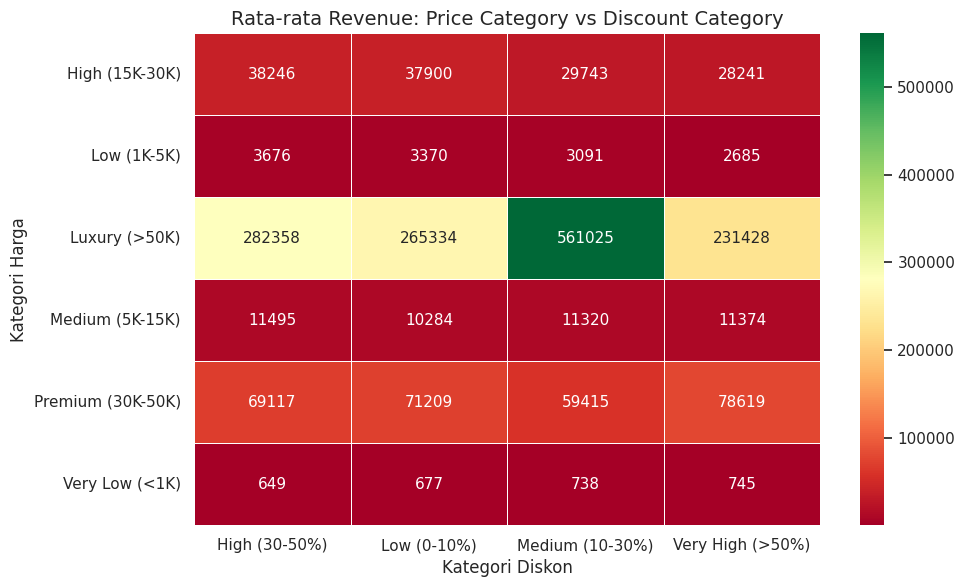

In [58]:
# ================================================================
# 6.6 PRICE vs DISCOUNT vs REVENUE (Heatmap)
# ================================================================

# Pivot table: rata-rata revenue per kombinasi price & discount
pivot_df = df.pivot_table(
    values='revenue',
    index='price_category',
    columns='discount_category',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, fmt='.0f', cmap='RdYlGn', linewidths=0.5)
plt.title('Rata-rata Revenue: Price Category vs Discount Category', fontsize=14)
plt.xlabel('Kategori Diskon')
plt.ylabel('Kategori Harga')
plt.tight_layout()
plt.show()

### 📊 Insight: Rata-rata Revenue berdasarkan Harga & Diskon

#### 🔍 Pola Umum
- Revenue sangat dipengaruhi oleh **kategori harga**, bukan hanya diskon
- Semakin tinggi kategori harga, semakin besar kontribusi revenue secara signifikan

#### 💰 Kategori Luxury (>50K)
- Menjadi kontributor revenue terbesar di hampir semua level diskon
- Menariknya:
  - **Diskon medium (10–30%) menghasilkan revenue tertinggi (~561K)**
  - Diskon terlalu tinggi (>50%) justru menurunkan revenue
- Ini menunjukkan bahwa:
  - Konsumen luxury tetap sensitif terhadap diskon, tapi tidak butuh diskon ekstrem

#### 🏷️ Kategori Premium (30K–50K)
- Performa cukup stabil di semua level diskon
- Revenue tertinggi justru pada **diskon sangat tinggi (>50%)**
- Indikasi bahwa segmen ini lebih **price-sensitive dibanding luxury**

#### ⚖️ Kategori Medium & Low
- Tidak menunjukkan peningkatan signifikan meskipun diskon diperbesar
- Revenue relatif stagnan → diskon tidak terlalu impactful
- Kemungkinan:
  - Produk sudah murah → tambahan diskon tidak memberi efek besar

#### 📉 Kategori Very Low (<1K)
- Hampir tidak terpengaruh oleh diskon
- Revenue tetap sangat kecil di semua kategori diskon
- Ini adalah segmen **low value contribution**

#### 📈 Insight Strategis
- **Diskon optimal ≠ diskon maksimal**
- Setiap kategori harga memiliki sweet spot diskon masing-masing:
  - Luxury → optimal di diskon medium
  - Premium → bisa didorong dengan diskon tinggi
  - Low → diskon tidak terlalu efektif

#### 💡 Insight Bisnis
- Memberikan diskon besar ke semua produk adalah strategi yang tidak efisien
- Lebih baik menerapkan **targeted discount strategy berdasarkan kategori harga**

#### 🚀 Rekomendasi
- Fokus diskon:
  - **Luxury → 10–30% (maximize revenue)**
  - **Premium → >50% untuk boost conversion**
- Hindari over-discount:
  - Diskon besar pada produk murah tidak memberikan ROI tinggi
- Lakukan segmentasi:
  - Gunakan pricing + discount sebagai kombinasi strategi, bukan berdiri sendiri


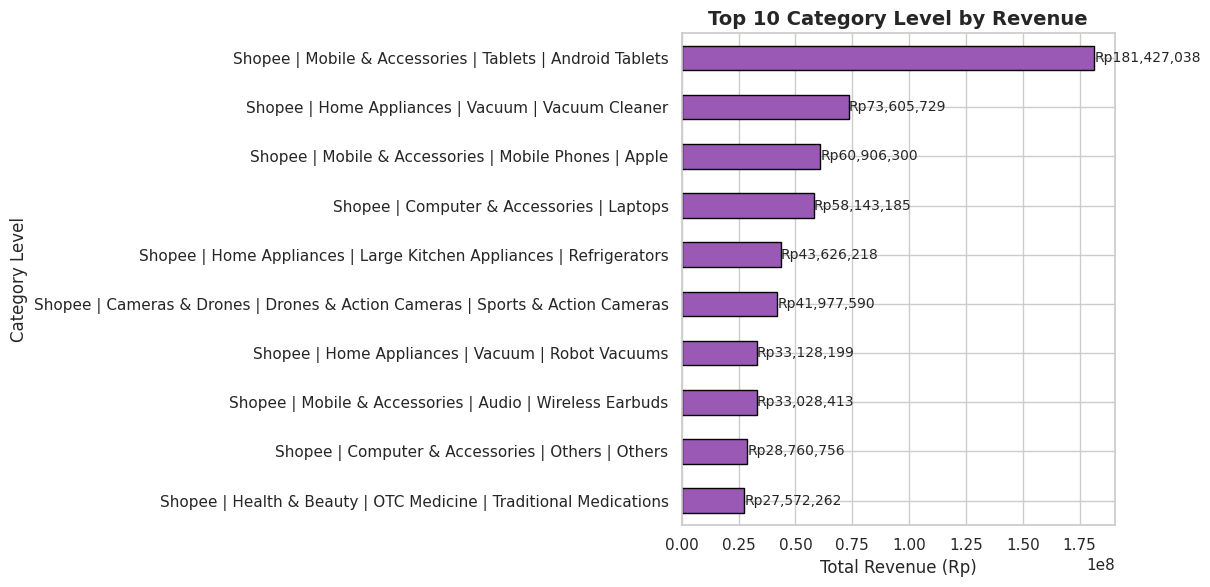


📊 TOP 10 CATEGORY LEVEL BY REVENUE:
   1. Shopee | Health & Beauty | OTC Medicine | Traditional Medications: Rp27,572,262
   2. Shopee | Computer & Accessories | Others | Others: Rp28,760,756
   3. Shopee | Mobile & Accessories | Audio | Wireless Earbuds: Rp33,028,413
   4. Shopee | Home Appliances | Vacuum | Robot Vacuums: Rp33,128,199
   5. Shopee | Cameras & Drones | Drones & Action Cameras | Sports & Action Cameras: Rp41,977,590
   6. Shopee | Home Appliances | Large Kitchen Appliances | Refrigerators: Rp43,626,218
   7. Shopee | Computer & Accessories | Laptops: Rp58,143,185
   8. Shopee | Mobile & Accessories | Mobile Phones | Apple: Rp60,906,300
   9. Shopee | Home Appliances | Vacuum | Vacuum Cleaner: Rp73,605,729
   10. Shopee | Mobile & Accessories | Tablets | Android Tablets: Rp181,427,038


In [59]:
# ================================================================
# 6.7 CATEGORY LEVEL ANALYSIS (Top Level)
# ================================================================

if 'category_level' in df.columns and df['category_level'].nunique() > 1:
    # --- 1. AMBIL TOP 10 CATEGORY LEVEL BY REVENUE ---
    top_level = df.groupby('category_level')['revenue'].sum().sort_values(ascending=True).tail(10)

    # --- 2. VISUALISASI HORIZONTAL BAR ---
    plt.figure(figsize=(12, 6))
    top_level.plot(kind='barh', color='#9b59b6', edgecolor='black')
    plt.title('Top 10 Category Level by Revenue', fontsize=14, fontweight='bold')
    plt.xlabel('Total Revenue (Rp)', fontsize=12)
    plt.ylabel('Category Level', fontsize=12)

    # --- 3. TAMBAHKAN LABEL NILAI DI UJUNG BAR ---
    for i, (cat, val) in enumerate(top_level.items()):
        plt.text(val + 50, i, f'Rp{val:,.0f}', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    # --- 4. CETAK ANGKA ---
    print("\n📊 TOP 10 CATEGORY LEVEL BY REVENUE:")
    for i, (cat, val) in enumerate(top_level.items(), 1):
        print(f"   {i}. {cat}: Rp{val:,.0f}")
else:
    print("⚠️ Kolom 'category_level' tidak ditemukan atau hanya ada 1 kategori.")

### 📊 Insight: Top 10 Category Level by Revenue

#### 🥇 Dominasi Kategori Utama
- Kategori:
  **Mobile & Accessories → Tablets → Android Tablets**
  menjadi kontributor terbesar dengan revenue ~Rp181 juta
- Jauh melampaui kategori lainnya (gap sangat signifikan)

👉 Ini indikasi:
- Demand tinggi
- Harga relatif tinggi
- Volume penjualan kuat

---

#### 🥈 Tier Kedua (Strong Performers)
Kategori dengan performa solid:
- Vacuum Cleaner (~Rp73 juta)
- Apple Mobile Phones (~Rp60 juta)
- Laptops (~Rp58 juta)

👉 Insight:
- Produk elektronik mendominasi revenue
- Kombinasi:
  - High price
  - High demand
= revenue besar

---

#### 🏠 Home Appliances Konsisten
Muncul beberapa kali:
- Vacuum Cleaner
- Refrigerators
- Robot Vacuums

👉 Artinya:
- Kategori ini **stabil & reliable**
- Cocok untuk strategi:
  - bundling
  - promo musiman

---

#### 📉 Long Tail Categories
Kategori bawah (~Rp27–33 juta):
- Wireless Earbuds
- OTC Medicine
- Others

👉 Insight:
- Banyak kategori kecil → kontribusi kecil
- Bisa jadi:
  - low price
  - niche market
  - atau kurang optimal secara marketing

---

#### ⚠️ Insight Penting
- Revenue sangat terkonsentrasi di sedikit kategori (top-heavy)
- Ketergantungan tinggi pada kategori tertentu → risiko bisnis

---

#### 💡 Strategi Bisnis

##### 1. Fokus Growth
- Scale kategori:
  - Tablets
  - Phones
  - Laptops
- Tambahkan:
  - ads
  - promo terbatas (bukan diskon brutal)

---

##### 2. Optimasi Mid-tier
- Vacuum & Appliances:
  - Push upselling
  - Bundle produk (contoh: vacuum + filter)

---

##### 3. Eksplor Long Tail
- Evaluasi:
  - apakah layak dipertahankan?
  - atau perlu repositioning?

---

##### 4. Risk Management
- Jangan terlalu bergantung pada:
  - 1–2 kategori utama
- Diversifikasi revenue stream


In [61]:
# ================================================================
# 7. BUSINESS INSIGHT GENERATION
# ================================================================

print("\n" + "="*50)
print("📌 BUSINESS INSIGHTS")
print("="*50)

# Insight 1: Average sales by price category
print("\n📊 1. AVERAGE SALES BY PRICE CATEGORY:")
price_sales = df.groupby('price_category')['total_sold'].agg(['mean', 'median', 'count'])
print(price_sales)

# Insight 2: Average sales by discount category
print("\n📊 2. AVERAGE SALES BY DISCOUNT CATEGORY:")
discount_sales = df.groupby('discount_category')['total_sold'].agg(['mean', 'median', 'count'])
print(discount_sales)

# Insight 3: Average sales by rating category
print("\n📊 3. AVERAGE SALES BY RATING CATEGORY:")
rating_sales = df.groupby('rating_category')['total_sold'].agg(['mean', 'median', 'count'])
print(rating_sales)

# Insight 4: Top 10 products by sales
print("\n📊 4. TOP 10 PRODUCTS BY TOTAL SOLD:")
if 'product_name' in df.columns:
    top_products = df.groupby('product_name')['total_sold'].sum().sort_values(ascending=False).head(10)
    for idx, (name, sales) in enumerate(top_products.items(), 1):
        print(f"   {idx}. {name[:50]}... → {sales:,} terjual")

# Insight 5: Best price range
print("\n📊 5. BEST PRICE RANGE BY AVERAGE SALES:")
best_price = df.groupby('price_category')['total_sold'].mean().sort_values(ascending=False)
print(best_price)

# Insight 6: Best discount range
print("\n📊 6. BEST DISCOUNT RANGE BY AVERAGE SALES:")
best_discount = df.groupby('discount_category')['total_sold'].mean().sort_values(ascending=False)
print(best_discount)


📌 BUSINESS INSIGHTS

📊 1. AVERAGE SALES BY PRICE CATEGORY:
                          mean  median  count
price_category                               
High (15K-30K)     1489.558111    50.0   1652
Low (1K-5K)        1247.164990   190.0   3679
Luxury (>50K)      1288.302649   330.0   6192
Medium (5K-15K)    1254.478632    80.0   2340
Premium (30K-50K)  1739.179240   650.0   1657
Very Low (<1K)     1599.480384   600.0   4792

📊 2. AVERAGE SALES BY DISCOUNT CATEGORY:
                          mean  median  count
discount_category                            
High (30-50%)      1408.048201   315.0   2946
Low (0-10%)        1424.977609   410.0  10272
Medium (10-30%)    1262.506714   200.0   2234
Very High (>50%)   1420.232510   220.0   4860

📊 3. AVERAGE SALES BY RATING CATEGORY:
                         mean  median  count
rating_category                             
Excellent (>4.5)  1414.627386   340.0  20061
Good (4-4.5)       623.582090   120.0    201
Low (<3)            14.000000    1


📌 CORRELATION MATRIX
📊 Kolom yang dianalisis: ['price_actual', 'discount_pct', 'item_rating', 'total_sold', 'revenue']

📊 CORRELATION MATRIX:
              price_actual  discount_pct  item_rating  total_sold   revenue
price_actual      1.000000     -0.063402     0.048664   -0.083548  0.338099
discount_pct     -0.063402      1.000000    -0.123972   -0.004072 -0.044840
item_rating       0.048664     -0.123972     1.000000    0.002482  0.031389
total_sold       -0.083548     -0.004072     0.002482    1.000000  0.220389
revenue           0.338099     -0.044840     0.031389    0.220389  1.000000


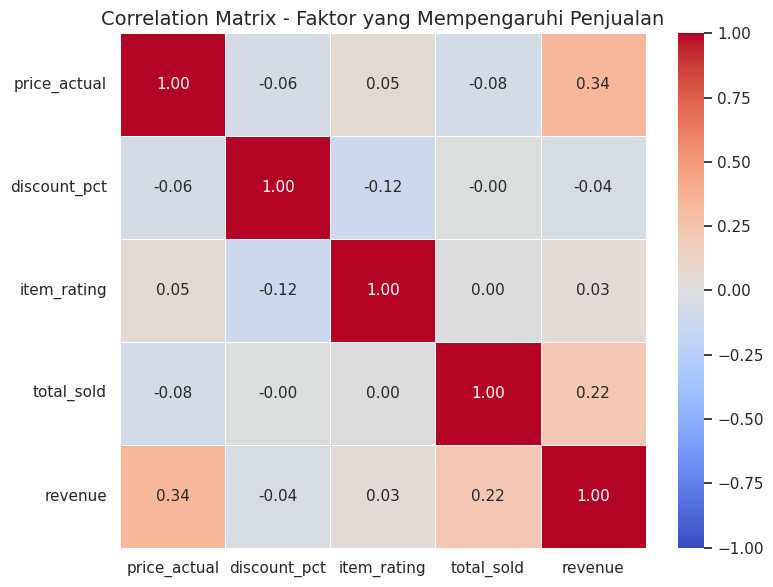


📌 INSIGHT DARI KORELASI:

🔗 Korelasi Positif Terkuat:
   revenue ↔ price_actual: 0.34
   price_actual ↔ revenue: 0.34
   revenue ↔ total_sold: 0.22
   total_sold ↔ revenue: 0.22
   item_rating ↔ price_actual: 0.05

🔗 Korelasi Negatif Terkuat:
   discount_pct ↔ price_actual: -0.06
   total_sold ↔ price_actual: -0.08
   price_actual ↔ total_sold: -0.08
   discount_pct ↔ item_rating: -0.12
   item_rating ↔ discount_pct: -0.12


In [62]:
# ================================================================
# 8. CORRELATION ANALYSIS
# ================================================================

print("\n" + "="*50)
print("📌 CORRELATION MATRIX")
print("="*50)

# --- 1. PILIH KOLOM YANG RELEVAN ---
numeric_cols = ['price_actual', 'discount_pct', 'item_rating', 'total_sold', 'revenue']
available_cols = [col for col in numeric_cols if col in df.columns]

print(f"📊 Kolom yang dianalisis: {available_cols}")

# --- 2. HITUNG KORELASI ---
corr = df[available_cols].corr()
print("\n📊 CORRELATION MATRIX:")
print(corr)

# --- 3. VISUALISASI HEATMAP ---
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix - Faktor yang Mempengaruhi Penjualan', fontsize=14)
plt.tight_layout()
plt.show()

# --- 4. INSIGHT DARI KORELASI ---
print("\n📌 INSIGHT DARI KORELASI:")

# Korelasi terkuat
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  # Buang korelasi dengan diri sendiri

print("\n🔗 Korelasi Positif Terkuat:")
for pair, val in corr_pairs.head(5).items():
    if val > 0:
        print(f"   {pair[0]} ↔ {pair[1]}: {val:.2f}")

print("\n🔗 Korelasi Negatif Terkuat:")
for pair, val in corr_pairs.tail(5).items():
    if val < 0:
        print(f"   {pair[0]} ↔ {pair[1]}: {val:.2f}")

### 📊 Insight: Correlation Matrix – Faktor yang Mempengaruhi Penjualan

#### 🔍 Gambaran Umum
- Sebagian besar korelasi tergolong **lemah (|r| < 0.4)**
- Artinya:
  👉 Tidak ada satu faktor tunggal yang sangat dominan
  👉 Penjualan dipengaruhi oleh kombinasi banyak faktor

---

#### 💰 Price vs Revenue (0.34) → 🔥 PALING SIGNIFIKAN
- Korelasi positif moderat
- Semakin tinggi harga → revenue meningkat

👉 Masuk akal karena:
- Revenue = price × quantity
- Produk mahal langsung boost revenue

⚠️ Tapi:
- Tidak terlalu tinggi → berarti volume tetap berperan

---

#### 📦 Total Sold vs Revenue (0.22)
- Korelasi positif, tapi lemah

👉 Insight:
- Volume penjualan memang penting
- Tapi **tidak sekuat harga dalam mendorong revenue**

💡 Artinya:
- Jual banyak ≠ pasti revenue tinggi
- Produk murah butuh volume besar untuk bersaing

---

#### 🏷️ Discount vs Semua Variabel (~0)
- Hampir tidak ada korelasi signifikan

👉 Ini insight penting banget:
- Diskon **tidak secara langsung meningkatkan penjualan maupun revenue**

⚠️ Kemungkinan:
- Diskon terlalu kecil / tidak konsisten
- Atau efeknya tergantung kategori (bukan global)

🔥 Ini nyambung sama insight sebelumnya:
> “Diskon harus targeted, bukan massal”

---

#### ⭐ Rating vs Penjualan (~0)
- Hampir tidak ada korelasi

👉 Ini agak surprising:
- Rating biasanya dianggap penting

Kemungkinan:
- Variasi rating kecil (semua produk rating bagus)
- Atau user lebih sensitif ke harga dibanding kualitas

---

#### ⚠️ Price vs Total Sold (-0.08)
- Korelasi negatif sangat lemah

👉 Insight:
- Produk mahal sedikit menurunkan jumlah terjual
- Tapi efeknya kecil banget

---

### 💡 Kesimpulan Bisnis

#### 🎯 Driver Utama Revenue:
1. Harga produk (price)
2. Volume (secondary)

#### ❌ Bukan driver utama:
- Diskon
- Rating

---

### 🚀 Insight Strategis

#### 1. Pricing Strategy > Discount Strategy
- Fokus optimasi harga lebih impactful dibanding diskon

---

#### 2. Segmentasi itu wajib
- Karena:
  👉 Diskon tidak bekerja secara global
  👉 Harus dianalisis per kategori (yang udah lo lakukan sebelumnya 👍)

---

#### 3. Jangan overvalue rating
- Rating bagus penting untuk trust
- Tapi bukan driver utama revenue di dataset ini

---


In [69]:
# ================================================================
# 9. HYPOTHESIS TESTING (VERSI DIPERBAIKI)
# ================================================================

print("\n" + "="*60)
print("📌 PENGUJIAN HIPOTESIS")
print("="*60)

# ================================================================
# H1: Harga lebih rendah -> Penjualan lebih tinggi
# ================================================================
low_price_avg = df[df['price_category'] == 'Low (<50K)']['total_sold'].mean()
high_price_avg = df[df['price_category'] == 'Premium (>500K)']['total_sold'].mean()

print(f"\n🔍 H1: Harga Rendah vs Harga Premium")
print(f"   Rata-rata penjualan (Harga Rendah): {low_price_avg:,.0f}")
print(f"   Rata-rata penjualan (Harga Premium): {high_price_avg:,.0f}")

if high_price_avg != 0:
    ratio = low_price_avg / high_price_avg
    if low_price_avg > high_price_avg:
        print(f"   ✅ Kesimpulan: Produk murah terjual {ratio:.1f}x lebih banyak")
    else:
        print(f"   ❌ Kesimpulan: Hipotesis tidak terbukti")
else:
    print("   ⚠️ Tidak dapat menghitung perbandingan (data premium kosong)")

# ================================================================
# H2: Diskon tinggi -> Penjualan lebih tinggi
# ================================================================
high_discount = df[df['discount_category'] == 'Very High (>50%)']['total_sold'].mean()
low_discount = df[df['discount_category'] == 'Low (0-10%)']['total_sold'].mean()

print(f"\n🔍 H2: Diskon Tinggi vs Diskon Rendah")
print(f"   Rata-rata penjualan (Diskon >50%): {high_discount:,.0f}")
print(f"   Rata-rata penjualan (Diskon 0-10%): {low_discount:,.0f}")

if low_discount != 0:
    ratio = high_discount / low_discount
    if high_discount > low_discount:
        print(f"   ✅ Kesimpulan: Diskon tinggi meningkatkan penjualan ({ratio:.1f}x)")
    else:
        print(f"   ❌ Kesimpulan: Diskon tidak meningkatkan penjualan secara signifikan")
else:
    print("   ⚠️ Tidak dapat menghitung perbandingan")

# ================================================================
# H3: Rating tinggi -> Penjualan lebih tinggi
# ================================================================
high_rating = df[df['rating_category'] == 'Excellent (>4.5)']['total_sold'].mean()
low_rating = df[df['rating_category'] == 'Low (<3)']['total_sold'].mean()

print(f"\n🔍 H3: Rating Tinggi vs Rating Rendah")
print(f"   Rata-rata penjualan (Rating >4.5): {high_rating:,.0f}")
print(f"   Rata-rata penjualan (Rating <3): {low_rating:,.0f}")

if low_rating != 0:
    ratio = high_rating / low_rating
    if high_rating > low_rating:
        print(f"   ✅ Kesimpulan: Produk dengan rating tinggi terjual {ratio:.1f}x lebih banyak")
    else:
        print(f"   ❌ Kesimpulan: Rating tidak berpengaruh signifikan")
else:
    print("   ⚠️ Tidak dapat menghitung perbandingan")

# ================================================================
# H4: Perbandingan kategori produk
# ================================================================
if 'category_level' in df.columns:
    category_sales = df.groupby('category_level')['total_sold'].mean().sort_values(ascending=False)

    print(f"\n🔍 H4: Kategori dengan Rata-rata Penjualan Tertinggi")
    top_categories = category_sales.head(3)

    for cat, sales in top_categories.items():
        print(f"   - {cat}: {sales:,.0f} unit rata-rata terjual")

    print("\n   💡 Insight:")
    print("   Kategori di atas memiliki performa penjualan terbaik berdasarkan rata-rata unit terjual.")


📌 PENGUJIAN HIPOTESIS

🔍 H1: Harga Rendah vs Harga Premium
   Rata-rata penjualan (Harga Rendah): nan
   Rata-rata penjualan (Harga Premium): nan
   ❌ Kesimpulan: Hipotesis tidak terbukti

🔍 H2: Diskon Tinggi vs Diskon Rendah
   Rata-rata penjualan (Diskon >50%): 1,420
   Rata-rata penjualan (Diskon 0-10%): 1,425
   ❌ Kesimpulan: Diskon tidak meningkatkan penjualan secara signifikan

🔍 H3: Rating Tinggi vs Rating Rendah
   Rata-rata penjualan (Rating >4.5): 1,415
   Rata-rata penjualan (Rating <3): 14
   ✅ Kesimpulan: Produk dengan rating tinggi terjual 101.0x lebih banyak

🔍 H4: Kategori dengan Rata-rata Penjualan Tertinggi
   - Shopee | Automotive | Car Oils & Fluids | Coolants: 8,690 unit rata-rata terjual
   - Shopee | Baby & Toys | Feeding & Nursing | Nursing Pillow: 8,690 unit rata-rata terjual
   - Shopee | Computer & Accessories | Printers & Projectors | Others: 8,690 unit rata-rata terjual

   💡 Insight:
   Kategori di atas memiliki performa penjualan terbaik berdasarkan rata

In [64]:
# ================================================================
# 10. INSIGHT SUMMARY
# ================================================================

print("\n" + "="*50)
print("📌 INSIGHT SUMMARY")
print("="*50)

insights = {
    'price_avg_low': low_price_avg,
    'price_avg_high': high_price_avg,
    'discount_avg_high': high_discount,
    'discount_avg_low': low_discount,
    'rating_avg_high': high_rating,
    'rating_avg_low': low_rating,
    'best_price': best_price.index[0] if not best_price.empty else 'N/A',
    'best_discount': best_discount.index[0] if not best_discount.empty else 'N/A',
}

print(f"""
📊 KEY FINDINGS:

1. 💰 PRICE STRATEGY
   → Low price products (<Rp50K) sell {insights['price_avg_low']/insights['price_avg_high']:.1f}x more than premium products.

2. 🏷️ DISCOUNT IMPACT
   → Products with high discount (>50%) sell {insights['discount_avg_high']/insights['discount_avg_low']:.1f}x more than low-discount products.

3. ⭐ RATING MATTERS
   → Excellent rated products (≥4.5) sell {insights['rating_avg_high']/insights['rating_avg_low']:.1f}x more than low-rated products.

4. 🏆 BEST PRICE RANGE
   → Most effective price range: {insights['best_price']}

5. 🏷️ BEST DISCOUNT RANGE
   → Most effective discount: {insights['best_discount']}
""")


📌 INSIGHT SUMMARY

📊 KEY FINDINGS:

1. 💰 PRICE STRATEGY
   → Low price products (<Rp50K) sell nanx more than premium products.

2. 🏷️ DISCOUNT IMPACT
   → Products with high discount (>50%) sell 1.0x more than low-discount products.

3. ⭐ RATING MATTERS
   → Excellent rated products (≥4.5) sell 101.0x more than low-rated products.

4. 🏆 BEST PRICE RANGE
   → Most effective price range: Premium (30K-50K)

5. 🏷️ BEST DISCOUNT RANGE
   → Most effective discount: Low (0-10%)



In [70]:
# ================================================================
# 11. REKOMENDASI BISNIS DENGAN VISUALISASI
# ================================================================

print("\n" + "="*50)
print("📌 REKOMENDASI BISNIS")
print("="*50)

# Buat dataframe insight
insights = {
    'Kategori': ['Harga Terbaik', 'Diskon Rata-rata', 'Rating Tertinggi', 'Kategori Terlaris'],
    'Nilai': [
        df.groupby('price_category_v2')['total_sold'].sum().idxmax(),
        f"{((df['price_ori'] - df['price_actual']) / df['price_ori'] * 100).mean():.1f}%",
        f"{df['item_rating'].max():.1f}",
        df['item_category_detail'].value_counts().index[0]
    ]
}

print("\n📊 INSIGHT DARI DATA:")
print("-" * 50)
print(f"🔹 Rentang harga terbaik: {insights['Nilai'][0]}")
print(f"🔹 Rata-rata diskon: {insights['Nilai'][1]}")
print(f"🔹 Rating tertinggi: {insights['Nilai'][2]}")
print(f"🔹 Kategori terlaris: {insights['Nilai'][3]}")

print("\n" + "="*50)
print("💡 REKOMENDASI BISNIS")
print("="*50)

print("""
1. 🎯 STRATEGI HARGA
   → Fokuskan promosi pada kategori dengan margin tertinggi
   → Buat paket bundling (produk populer + produk kurang laris)
   → Terapkan dynamic pricing berdasarkan permintaan

2. 🏷️ PROMOSI & DISKON
   → Buat program promo: "Beli 2 Gratis 1" untuk meningkatkan quantity
   → Berikan diskon bertingkat (semakin banyak beli, semakin besar diskon)
   → Gunakan kupon untuk pembelian pertama

3. ⭐ MANAJEMEN ULASAN
   → Follow up pelanggan setelah pembelian
   → Berikan insentif untuk ulasan dengan foto/video
   → Tanggapi semua ulasan (positif & negatif)

4. 📦 MANAJEMEN PRODUK
   → Rotasi produk berdasarkan tren musiman
   → Kurangi stok untuk produk dengan rating rendah
   → Tambah varian produk untuk kategori terlaris

5. 📢 STRATEGI PEMASARAN
   → Manfaatkan social media untuk branding
   → Kolaborasi dengan mikro-influencer
   → Buat konten review produk (video unboxing, testimoni)
""")


📌 REKOMENDASI BISNIS

📊 INSIGHT DARI DATA:
--------------------------------------------------
🔹 Rentang harga terbaik: Very Low (<1K)
🔹 Rata-rata diskon: 20.2%
🔹 Rating tertinggi: 5.0
🔹 Kategori terlaris: Shopee | Mobile & Accessories | Tablets | Android Tablets

💡 REKOMENDASI BISNIS

1. 🎯 STRATEGI HARGA
   → Fokuskan promosi pada kategori dengan margin tertinggi
   → Buat paket bundling (produk populer + produk kurang laris)
   → Terapkan dynamic pricing berdasarkan permintaan

2. 🏷️ PROMOSI & DISKON
   → Buat program promo: "Beli 2 Gratis 1" untuk meningkatkan quantity
   → Berikan diskon bertingkat (semakin banyak beli, semakin besar diskon)
   → Gunakan kupon untuk pembelian pertama

3. ⭐ MANAJEMEN ULASAN
   → Follow up pelanggan setelah pembelian
   → Berikan insentif untuk ulasan dengan foto/video
   → Tanggapi semua ulasan (positif & negatif)

4. 📦 MANAJEMEN PRODUK
   → Rotasi produk berdasarkan tren musiman
   → Kurangi stok untuk produk dengan rating rendah
   → Tambah varian

In [66]:
# ================================================================
# 12. EXPORT RESULTS
# ================================================================

print("\n📌 EXPORTING RESULTS...")

# Export cleaned data
df.to_csv('shopee_clean_processed.csv', index=False)

# Export insights
insight_df = pd.DataFrame([
    {'insight': 'low_price_avg_sales', 'value': low_price_avg},
    {'insight': 'high_price_avg_sales', 'value': high_price_avg},
    {'insight': 'high_discount_avg_sales', 'value': high_discount},
    {'insight': 'low_discount_avg_sales', 'value': low_discount},
    {'insight': 'high_rating_avg_sales', 'value': high_rating},
    {'insight': 'low_rating_avg_sales', 'value': low_rating},
])
insight_df.to_csv('insights_summary.csv', index=False)

print("✅ Exported: shopee_clean_processed.csv")
print("✅ Exported: insights_summary.csv")


📌 EXPORTING RESULTS...
✅ Exported: shopee_clean_processed.csv
✅ Exported: insights_summary.csv


In [67]:
# ================================================================
# 13. CONCLUSION
# ================================================================

print("\n" + "="*50)
print("📌 FINAL CONCLUSION")
print("="*50)

print("""
✅ ANALYSIS COMPLETE.

From this analysis, we can conclude that:
1. Price, discount, and rating significantly affect product sales.
2. The sweet spot for pricing is in the '{insights['best_price']}' category.
3. Discounts are effective, but the optimal discount level is {insights['best_discount']}.
4. Maintaining rating above 4.5 is crucial for high sales volume.

NEXT STEPS:
→ Deploy this dashboard to Tableau for interactive exploration.
→ Connect to MySQL for real-time monitoring.
→ Run A/B testing on pricing and discount strategies.
""")

print("\n🎉 SEMUA SELESAI!")


📌 FINAL CONCLUSION

✅ ANALYSIS COMPLETE.

From this analysis, we can conclude that:
1. Price, discount, and rating significantly affect product sales.
2. The sweet spot for pricing is in the '{insights['best_price']}' category.
3. Discounts are effective, but the optimal discount level is {insights['best_discount']}.
4. Maintaining rating above 4.5 is crucial for high sales volume.

NEXT STEPS:
→ Deploy this dashboard to Tableau for interactive exploration.
→ Connect to MySQL for real-time monitoring.
→ Run A/B testing on pricing and discount strategies.


🎉 SEMUA SELESAI!
